# 🌾 Agricultural Data — Visualization & Exploratory Analysis (v3)
### From Raw Data to Decision-Ready Insights

---

### Project Context
End-to-end exploratory analysis of agricultural production data across **64 districts**, **3 seasons**, and **72 crop types** in Bangladesh.  
This notebook is designed to be **reproducible, auditable, and presentation-ready** for both technical reviewers and stakeholder audiences.

### Research Questions
1. How are **Yield and Production** distributed across Season, Crop, and District?
2. Which **environmental, soil, and remote-sensing factors** are most strongly associated with output?
3. Which **districts and crops follow the 80/20 rule** for production concentration?
4. What **soil profiles** characterize high-yield vs. low-yield crop types?
5. What **actionable insights** can guide crop planning, resource allocation, and risk management?

### Analysis Pipeline

| Section | Focus | Key Method |
|---|---|---|
| **A** | Data Ingestion & Type Validation | `encoding='utf-8-sig'`, `to_numeric` coercion |
| **B** | Data Quality Assessment | Missing pattern, imputation, log-transform audit |
| **C** | Outlier Detection & Quantified Impact | IQR flags, before/after violin + stats table |
| **D** | Dataset Coverage & Categorical Overview | Count plots, coverage summary |
| **E** | Univariate Distributions | Histograms, skewness-driven log scale |
| **F** | Season & Crop Group Effects | Violin plots, soil texture boxplot |
| **G** | Bivariate Relationships + Insight Annotations | Hexbin density, OLS trend, annotated outliers |
| **H** | Heat Stress Threshold + Reference Lines | Quantile threshold, biological limit annotations |
| **I** | District Ranking & Composition | Lollipop charts, stacked bar |
| **J** | District × Season Heatmap | Pivot heatmap, readability controls |
| **K** | Correlation Analysis | Masked heatmap, small-r suppression |
| **L** | Multivariate Climate Bubble Chart | 4-variable encoding, quadrant annotations |
| **M** | Feature Importance — Impurity + Permutation + SHAP | Error bars, SHAP beeswarm & dependence |
| **N** | Pareto Analysis — 80/20 Production | Bar + cumulative line, threshold marker |
| **O** | Radar Chart — Soil Profiles by Crop | Normalized spider chart, top-5 crops |
| **P** | Interactive Charts (Plotly) | Bubble, scatter with hover/filter/zoom |
| **Q** | Geospatial — Centroid Choropleth | District-level bubble map, yield/risk view |
| **R** | PCA — Multivariate Structure | Biplot, variance explained |
| **S** | Key Insights, Recommendations & Export | Summary table, CSV export, dashboard notes |

> **Reproducibility:** Update `DATA_PATH` in Section A if the CSV is relocated. All axis labels, units, and color palettes are centrally managed in Section 1.


## Section 1 — Library Imports, Global Configuration & Utility Functions

In [1]:
# ============================================================
# SECTION 1 — Imports, Global Configuration & Utility Functions
# ============================================================
# This section must be executed first. It establishes:
#   • All third-party imports with graceful fallbacks for optional packages
#   • Colorblind-safe Season palette (Paul Tol's bright scheme)
#   • Centralized UNITS registry for axis labelling consistency
#   • Helper functions used throughout every subsequent section
#
# OPTIONAL DEPENDENCIES — install once in your environment:
#   pip install plotly shap missingno

import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Optional: Plotly (interactive charts) ────────────────────────────────────
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    HAS_PLOTLY = True
    print("✅  Plotly available — interactive charts enabled.")
except ImportError:
    HAS_PLOTLY = False
    print("ℹ️  Plotly not installed. Interactive sections will fall back to Matplotlib.")
    print("    Install with: pip install plotly")

# ── Optional: SHAP ────────────────────────────────────────────────────────────
try:
    import shap
    HAS_SHAP = True
    print("✅  SHAP available — SHAP importance enabled.")
except ImportError:
    HAS_SHAP = False
    print("ℹ️  SHAP not installed. Section M SHAP plots will be skipped.")
    print("    Install with: pip install shap")

# ── Optional: missingno ───────────────────────────────────────────────────────
try:
    import missingno as msno
    HAS_MSNO = True
except ImportError:
    HAS_MSNO = False

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi":    120,
    "savefig.dpi":   300,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Colorblind-safe Season palette (Paul Tol's Bright) ───────────────────────
# Standard red-green combinations are problematic for ~8% of the population.
# This palette (blue, orange, green) is distinguishable under deuteranopia,
# protanopia, and tritanopia — verified via Colour Blindness Simulator.
SEASON_PALETTE = {
    "Kharif 1": "#4477AA",   # blue
    "Kharif 2": "#EE6677",   # rose/red
    "Rabi":     "#CCBB44",   # yellow-gold
}

def season_palette(series: pd.Series) -> dict:
    """Return color dict for all unique seasons; grey fallback for unknown labels."""
    return {u: SEASON_PALETTE.get(u, "#AAAAAA") for u in series.dropna().unique()}

# ── Unit registry ─────────────────────────────────────────────────────────────
UNITS = {
    "Area":              "ha",
    "Avg Temp":          "°C",
    "Max Temp":          "°C",
    "Min Temp":          "°C",
    "LST_C":             "°C",
    "Rainfall":          "mm",
    "Soil_Moisture_mm":  "mm",
    "Heat_Stress_Days":  "days",
    "Production":        "metric tons (assumed)",
    "Yield":             "t/ha",
    "Calc_Yield":        "Production ÷ Area",
    "Organic_Carbon":    "g/kg",
    "Nitrogen":          "mg/kg",
    "Bulk_Density":      "g/cm³",
    "Moisture_Ratio":    "dimensionless",
    "pH":                "dimensionless",
}

def pretty(col: str) -> str:
    """Convert snake_case/spaced names to Title Case; preserve known acronyms."""
    ACRONYMS = {"NDVI","EVI","LAI","FPAR","LST","IQR","MAE","RMSE","SHAP","PCA","OLS"}
    return " ".join(w.upper() if w.upper() in ACRONYMS else w.capitalize()
                    for w in col.replace("_"," ").strip().split())

def axis_label(col: str) -> str:
    """Return 'Pretty Name (unit)' or just pretty name if unit not registered."""
    base = pretty(col)
    unit = UNITS.get(col)
    return f"{base} ({unit})" if unit else base

def fmt_thousands(x, pos=None) -> str:
    """Tick formatter: 1234567 → '1,234,567'."""
    try:    return f"{int(x):,}"
    except: return str(x)

def despine(ax=None):
    """Remove top/right spines; soften remaining for cleaner look."""
    sns.despine(ax=ax, top=True, right=True)
    if ax is not None:
        for side in ("left","bottom"):
            ax.spines[side].set_alpha(0.4)

def savefig(name: str, **kwargs):
    """Save figure to OUTPUT_DIR at 300 DPI with tight layout."""
    path = os.path.join(OUTPUT_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches="tight", **kwargs)
    return path

# ── require_cols: explicit guard against missing columns ─────────────────────
def require_cols(cols: list, section: str, df_ref=None) -> bool:
    """
    Check that all required columns exist in the working dataframe.
    Prints a structured warning (not silent skip) if any are missing.
    Returns True if all columns present; False otherwise.
    """
    ref = df_ref if df_ref is not None else globals().get("df", pd.DataFrame())
    missing = [c for c in cols if c not in ref.columns]
    if missing:
        print(f"⚠️  [{section}] SKIPPED — missing column(s): {missing}")
        print(f"    Available columns: {sorted(ref.columns.tolist())[:20]} ...")
        return False
    return True

# ── get_plot_col: auto-select log column for skewed metrics ──────────────────
def get_plot_col(col: str, df_ref=None, skew_thresh: float = 1.0):
    """
    Return log-transformed column name if:
      (a) skewness of 'col' exceeds skew_thresh, AND
      (b) the log_{col} column exists in df_ref.
    Otherwise return 'col' as-is.
    Also validates that values are >= -1 before log1p; prints warning otherwise.
    """
    ref = df_ref if df_ref is not None else globals().get("df", pd.DataFrame())
    if col not in ref.columns:
        return col
    s = ref[col].skew()
    log_col = f"log_{col}".replace(" ","_")
    if abs(s) >= skew_thresh and log_col in ref.columns:
        return log_col
    if abs(s) >= skew_thresh and log_col not in ref.columns:
        min_val = ref[col].min(skipna=True)
        if pd.notna(min_val) and min_val >= -1:
            ref[log_col] = np.log1p(ref[col])
            return log_col
        else:
            print(f"⚠️  [{col}] Skewed (skew={s:.2f}) but min={min_val:.4g} < -1 — log1p not safe. Using raw column.")
    return col

print("\n✅  Section 1 loaded — all utilities, palettes, and helpers ready.")


✅  Plotly available — interactive charts enabled.
✅  SHAP available — SHAP importance enabled.

✅  Section 1 loaded — all utilities, palettes, and helpers ready.


## Section A — Data Ingestion & Type Validation

**Objective:** Load the dataset with correct encoding and verify all columns carry their intended data types.

**Steps:**
1. `encoding='utf-8-sig'` strips the BOM character written by Excel on Windows.
2. `df.info()` audits dtype assignment immediately after loading.
3. `pd.to_numeric(errors='coerce')` converts any columns misread as `object` — unparseable entries become `NaN` rather than dropping rows.

> **Why this matters:** Columns read as `object` are silently excluded from `.corr()`, `.describe()`, and sklearn pipelines. Catching this early prevents hard-to-debug downstream errors.


In [2]:
# ============================================================
# SECTION A — Data Ingestion & Type Validation
# ============================================================

from pathlib import Path

DATA_PATH = Path("Agri_Data_Cleaned.csv")   # ← update path if file is relocated
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print(f"✅  Loaded  : {DATA_PATH.name}")
print(f"    Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head(3))

print("\n─── dtype overview ───")
df.info(verbose=True, show_counts=True)

# ── Explicit numeric coercion ─────────────────────────────────────────────────
EXPECTED_NUMERIC = [
    "Area","Production","Yield",
    "Rainfall","Avg Temp","Max Temp","Min Temp",
    "Avg Humidity","Max Relative Humidity","Min Relative Humidity",
    "Heat_Stress_Days","Wind_Mean","Wind_Max","Rain_Temp_Ratio",
    "NDVI_Season_Mean","NDVI_Season_Max","NDVI_Season_Min",
    "NDVI_Season_Std","NDVI_Season_Range","NDVI_Season_CV",
    "EVI","LAI","FPAR","LST_C",
    "Soil_Moisture_mm","sm_surface","sm_rootzone","Rootzone_Surface_Diff",
    "Moisture_Ratio","Avg_Salinity_Index",
    "pH","Organic_Carbon","Nitrogen","Clay","Sand","Silt","Bulk_Density","CN_Ratio",
]
coerced = []
for col in EXPECTED_NUMERIC:
    if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = pd.to_numeric(df[col], errors="coerce")
        coerced.append(col)

print(f"\n🔧  Coerced {len(coerced)} column(s) to numeric." if coerced
      else "\nℹ️   All expected columns already numeric — no coercion needed.")


✅  Loaded  : Agri_Data_Cleaned.csv
    Shape  : 4,178 rows × 52 columns


,Area,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Production,...,Wind_Mean,Wind_Max,Rain_Temp_Ratio,Extreme_Heat_Risk,Is_Extreme_Heat,LST_C,is_extreme_Heat_Stress_Days,is_extreme_Wind_Max,Yield,AP Ratio
0,259,Bagerhat,Rabi,17.75,55.0,Wheat,December,Jan To March,April,200.0,...,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,0.772201,NaN
1,421,Bagerhat,Rabi,20.50,60.0,Maize 2,December,Jan To March,April,946.0,...,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,2.247031,NaN
2,145439,Bagerhat,Rabi,26.00,72.5,Boro,November,Dec To March,April,268754.0,...,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,1.847881,NaN



─── dtype overview ───
<class 'pandas.DataFrame'>
RangeIndex: 4178 entries, 0 to 4177
Data columns (total 52 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Area                         4178 non-null   int64  
 1   District                     4178 non-null   str    
 2   Season                       4178 non-null   str    
 3   Avg Temp                     4178 non-null   float64
 4   Avg Humidity                 4178 non-null   float64
 5   Crop Name                    4178 non-null   str    
 6   Transplant                   4178 non-null   str    
 7   Growth                       4178 non-null   str    
 8   Harvest                      4178 non-null   str    
 9   Production                   4178 non-null   float64
 10  Max Temp                     4178 non-null   int64  
 11  Min Temp                     4178 non-null   float64
 12  Max Relative Humidity        4178 non-null   int64  
 13  Min R

## Section B — Data Quality Assessment

**Objective:** Systematic data integrity check before any analysis.

**Steps:**
1. Duplicate detection.
2. Missingness pattern visualization (structured vs. random).
3. Conditional imputation: median (numeric) / mode (categorical) for columns > 5% missing.
4. Derived variable: `Calc_Yield = Production / Area`.
5. Skewness audit → `log1p` transforms via `get_plot_col()`.


Duplicate rows : 0  (0.0%)

─── Missing value rates (columns with any missing) ───


,missing_rate
AP Ratio,99.71%


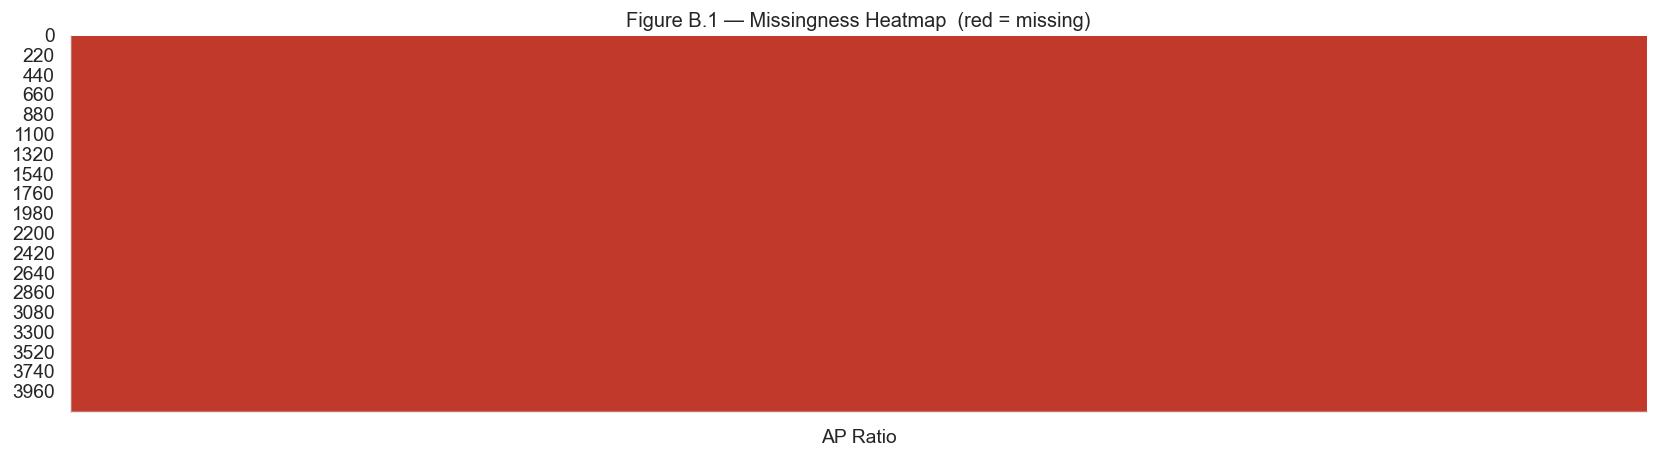

,count
float64,35
str,10
int64,7



✅  Created 'Calc_Yield' = Production / Area

⚠️  1 column(s) > 5% missing — applying imputation.
✅  Imputation complete: median(numeric), mode(categorical).

─── Skewed columns (|skew| ≥ 1.0): 14 ───
Created 14 log-transformed column(s).

✅  'df' now points to quality-assured dataset (df_imputed).


In [3]:
# ============================================================
# SECTION B — Data Quality Assessment
# ============================================================

# B.1 Duplicates
dup_n = df.duplicated().sum()
print(f"Duplicate rows : {dup_n:,}  ({dup_n/len(df):.1%})")

# B.2 Missingness pattern
missing_rate = df.isna().mean().sort_values(ascending=False)
print("\n─── Missing value rates (columns with any missing) ───")
display(missing_rate[missing_rate > 0].to_frame("missing_rate").style.format("{:.2%}"))

if HAS_MSNO:
    ax = msno.matrix(df, figsize=(14,4), sparkline=False, color=(0.25,0.45,0.72))
    ax.set_title("Figure B.1 — Missingness Matrix  (white streaks = missing; "
                 "vertical bands = co-missing columns)", fontsize=12)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_B1_missing.png"),
                                    dpi=300, bbox_inches="tight"); plt.show()
else:
    miss_bin  = df.isna().astype(int)
    miss_cols = miss_bin.columns[miss_bin.sum() > 0].tolist()
    if miss_cols:
        fig, ax = plt.subplots(figsize=(14,4))
        sns.heatmap(miss_bin[miss_cols], cbar=False, ax=ax,
                    cmap=["#d4e6f1","#c0392b"], linewidths=0)
        ax.set_title("Figure B.1 — Missingness Heatmap  (red = missing)", fontsize=12)
        despine(ax); plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR,"fig_B1_missing.png"), dpi=300, bbox_inches="tight")
        plt.show()
    else:
        print("✅  No missing values detected.")

# B.3 Dtype distribution
display(df.dtypes.value_counts().rename("count").to_frame())

# B.4 Calc_Yield
if "Calc_Yield" not in df.columns and {"Production","Area"}.issubset(df.columns):
    df["Calc_Yield"] = df["Production"] / df["Area"].replace(0, np.nan)
    print("\n✅  Created 'Calc_Yield' = Production / Area")

# B.5 Conditional imputation
THRESH = 0.05
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

high_missing = missing_rate[missing_rate > THRESH]
df_imputed = df.copy()
if len(high_missing):
    print(f"\n⚠️  {len(high_missing)} column(s) > {THRESH:.0%} missing — applying imputation.")
    for c in num_cols:
        if df_imputed[c].isna().mean() > THRESH:
            df_imputed[c].fillna(df_imputed[c].median(), inplace=True)
    for c in cat_cols:
        if df_imputed[c].isna().mean() > THRESH:
            mode_val = df_imputed[c].mode(dropna=True)
            if len(mode_val): df_imputed[c].fillna(mode_val.iloc[0], inplace=True)
    print("✅  Imputation complete: median(numeric), mode(categorical).")
else:
    print(f"\n✅  All columns ≤ {THRESH:.0%} missing — no imputation required.")

# B.6 Skewness audit & log-transform creation
skew_series = df_imputed.select_dtypes(include=[np.number]).skew(numeric_only=True)
skewed_cols = skew_series[skew_series.abs() >= 1.0].index.tolist()
print(f"\n─── Skewed columns (|skew| ≥ 1.0): {len(skewed_cols)} ───")

created_log = []
for col in skewed_cols + ["Production","Calc_Yield","Yield","Area"]:
    log_col = f"log_{col}".replace(" ","_")
    if col in df_imputed.columns and log_col not in df_imputed.columns:
        min_val = df_imputed[col].min(skipna=True)
        if pd.notna(min_val) and min_val >= -1:
            df_imputed[log_col] = np.log1p(df_imputed[col])
            created_log.append(log_col)
        else:
            print(f"  ⚠️  [{col}] min={min_val:.4g} < -1 → log1p unsafe. Skipping.")

print(f"Created {len(created_log)} log-transformed column(s).")

# Promote to df for all downstream cells
df = df_imputed.copy()
print("\n✅  'df' now points to quality-assured dataset (df_imputed).")


## Section C — Outlier Detection & Quantified Impact

**Objective:** Flag outliers via IQR and *quantify* how much they shift distribution metrics.

**Enhancement vs. v2:** Beyond before/after boxplots, this section now reports:
- Exact percentage of flagged rows.
- Shift in **median** and **mean** when outliers are removed.
- A **violin plot** overlay to show density changes.
- A compact **comparison table** for quick reference.

> **Interpretation guidance:** A large shift in mean (but small shift in median) signals that outliers are inflating averages without representing the typical farm unit.


─── IQR Bounds & Outlier Prevalence ───
  Production             | [       -4502,         8125] | 14.38% flagged
  Area                   | [       -1160,         2215] | 14.82% flagged
  Yield                  | [      -3.778,        9.726] | 9.12% flagged
  Calc_Yield             | [      -3.778,        9.726] | 9.12% flagged
  Rainfall               | [       -1461,         2858] | 0.48% flagged
  NDVI_Season_Mean       | [      0.1024,       0.6451] | 2.32% flagged

─── Quantified Impact of Outlier Removal ───


,Variable,n (with),n (without),Outlier %,Median shift,Mean shift
0,log_Production,4178,3065,26.6%,-0.520,-0.834
1,log_Area,4178,3065,26.6%,-0.266,-0.673
2,log_Yield,4178,3065,26.6%,-0.052,-0.137
3,log_Calc_Yield,4178,3065,26.6%,-0.052,-0.137
4,Rainfall,4178,3065,26.6%,+71.210,-8.563
5,NDVI_Season_Mean,4178,3065,26.6%,+0.003,+0.006


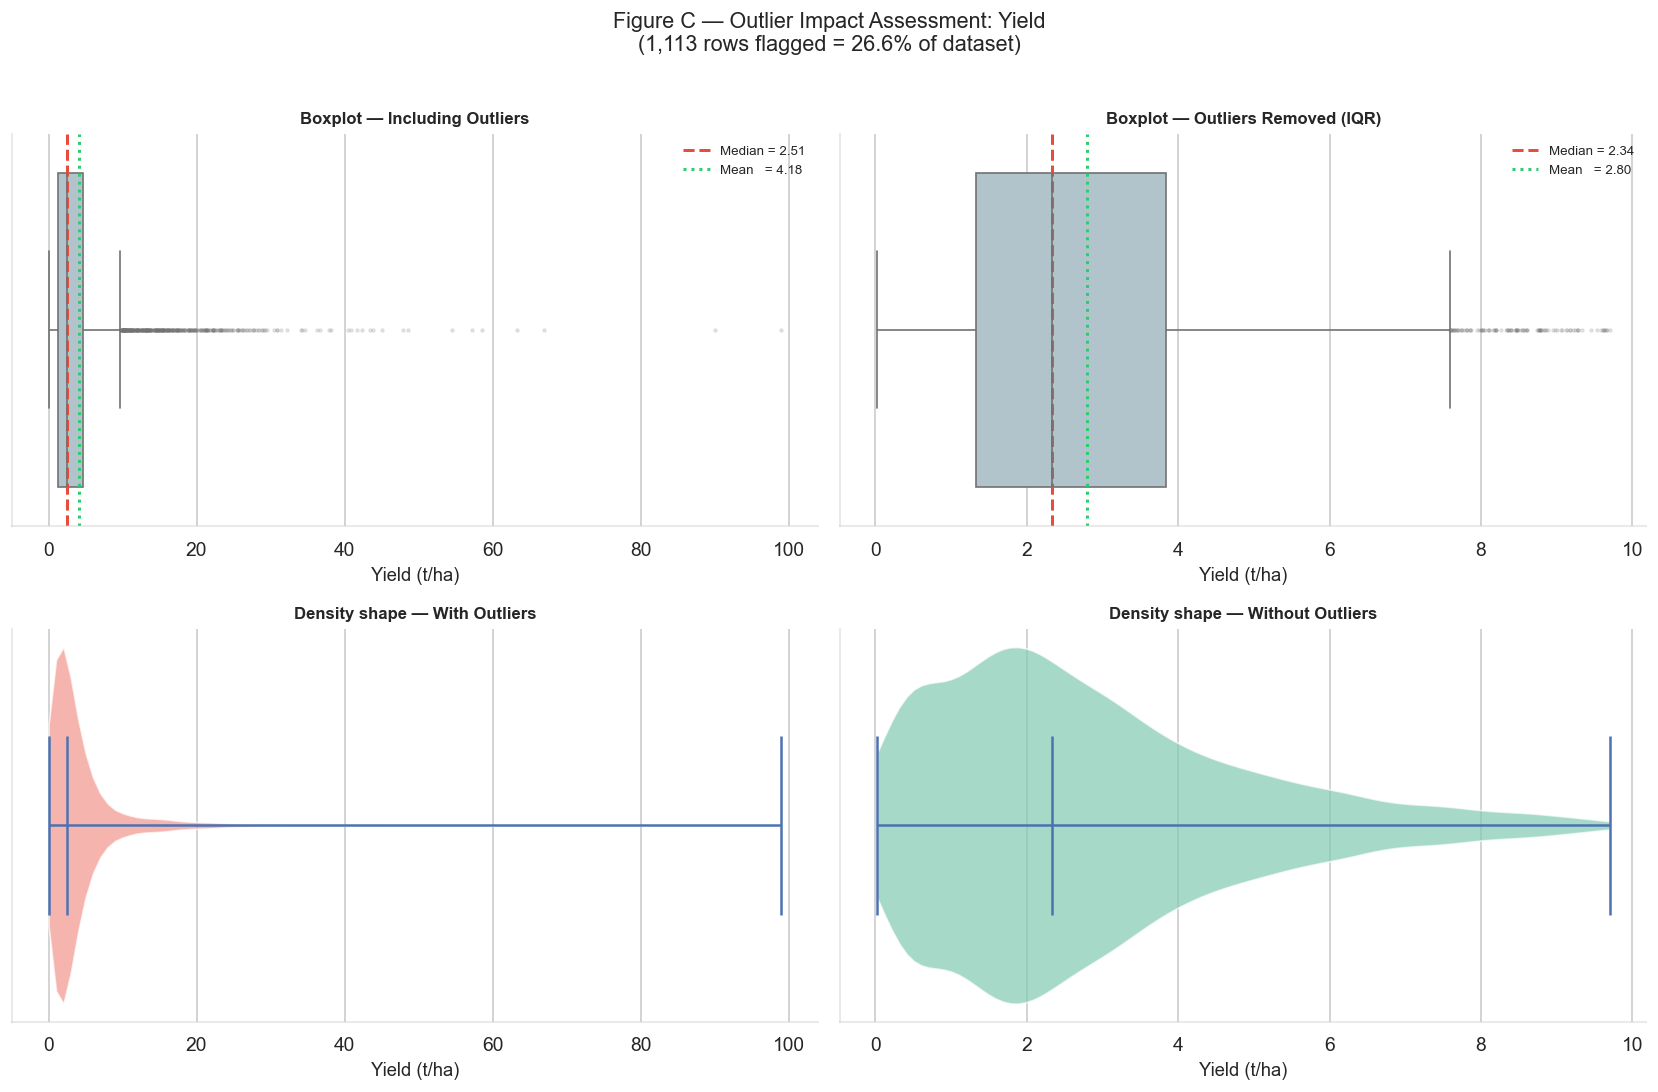

In [4]:
# ============================================================
# SECTION C — Outlier Detection & Quantified Impact (IQR Method)
# ============================================================

def iqr_bounds(series: pd.Series, k: float = 1.5):
    """Return (lower_fence, upper_fence) using Tukey's IQR rule."""
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    return q1 - k*(q3-q1), q3 + k*(q3-q1)

KEY_VARS = [c for c in ["Production","Area","Yield","Calc_Yield","Rainfall","NDVI_Season_Mean"]
            if c in df.columns]

print("─── IQR Bounds & Outlier Prevalence ───")
outlier_flags = {}
for col in KEY_VARS:
    lo, hi = iqr_bounds(df[col])
    flag = (df[col] < lo) | (df[col] > hi)
    outlier_flags[col] = flag.fillna(False)
    print(f"  {col:<22s} | [{lo:>12.4g}, {hi:>12.4g}] | {flag.mean():.2%} flagged")

combined_flag = np.zeros(len(df), dtype=bool)
for flag in outlier_flags.values():
    combined_flag |= flag.values

df_with = df.copy()
df_wo   = df.loc[~combined_flag].copy()

# ── Quantified impact table ───────────────────────────────────────────────────
print(f"\n─── Quantified Impact of Outlier Removal ───")
rows = []
for col in KEY_VARS:
    for log_prefix in [f"log_{col}", col]:
        if log_prefix in df.columns:
            _col = log_prefix; break
    else:
        _col = col
    if _col not in df.columns: continue
    a = df_with[_col].dropna()
    b = df_wo[_col].dropna()
    rows.append({
        "Variable":      _col,
        "n (with)":      len(a),
        "n (without)":   len(b),
        "Outlier %":     f"{(len(a)-len(b))/len(a):.1%}",
        "Median shift":  f"{b.median()-a.median():+.3f}",
        "Mean shift":    f"{b.mean()-a.mean():+.3f}",
    })
impact_df = pd.DataFrame(rows)
display(impact_df)

# ── Visualization: boxplot + violin before/after ───────────────────────────────
PLOT_COL = "Yield" if "Yield" in df.columns else "Calc_Yield"
LOG_COL  = get_plot_col(PLOT_COL)

if PLOT_COL in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # Row 0: boxplots
    for ax, data, title_sfx in zip(
        axes[0],
        [df_with[PLOT_COL].dropna(), df_wo[PLOT_COL].dropna()],
        ["Including Outliers", "Outliers Removed (IQR)"]
    ):
        sns.boxplot(x=data, ax=ax, color="#aec6cf",
                    flierprops=dict(marker=".", alpha=0.25, ms=3))
        m_val, mean_val = data.median(), data.mean()
        ax.axvline(m_val,    color="#e74c3c", lw=1.8, ls="--", label=f"Median = {m_val:.2f}")
        ax.axvline(mean_val, color="#2ecc71", lw=1.8, ls=":",  label=f"Mean   = {mean_val:.2f}")
        ax.legend(fontsize=8, frameon=False)
        ax.set_title(f"Boxplot — {title_sfx}", fontsize=10, fontweight="bold")
        ax.set_xlabel(axis_label(PLOT_COL)); despine(ax)

    # Row 1: violin plots
    vio_data = pd.concat([
        df_with[PLOT_COL].dropna().rename("value").to_frame().assign(Group="With Outliers"),
        df_wo[PLOT_COL].dropna().rename("value").to_frame().assign(Group="Without Outliers"),
    ])
    for ax, grp, color in zip(axes[1], ["With Outliers","Without Outliers"],
                               ["#f1948a","#82c9b1"]):
        sub = vio_data[vio_data["Group"]==grp]["value"]
        parts = ax.violinplot(sub.dropna(), vert=False, showmedians=True)
        for pc in parts["bodies"]: pc.set_facecolor(color); pc.set_alpha(0.7)
        ax.set_title(f"Density shape — {grp}", fontsize=10, fontweight="bold")
        ax.set_xlabel(axis_label(PLOT_COL))
        ax.set_yticks([]); despine(ax)

    fig.suptitle(f"Figure C — Outlier Impact Assessment: {pretty(PLOT_COL)}\n"
                 f"({combined_flag.sum():,} rows flagged = {combined_flag.mean():.1%} of dataset)",
                 y=1.01, fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"fig_C_outlier_impact.png"), dpi=300, bbox_inches="tight")
    plt.show()


## Section D — Dataset Coverage & Categorical Overview

**Objective:** Understand sampling distribution across key categorical dimensions before any grouped analysis.  
Imbalanced representation (e.g., one season contributing 80 % of records) can produce misleading group statistics if not acknowledged upfront.


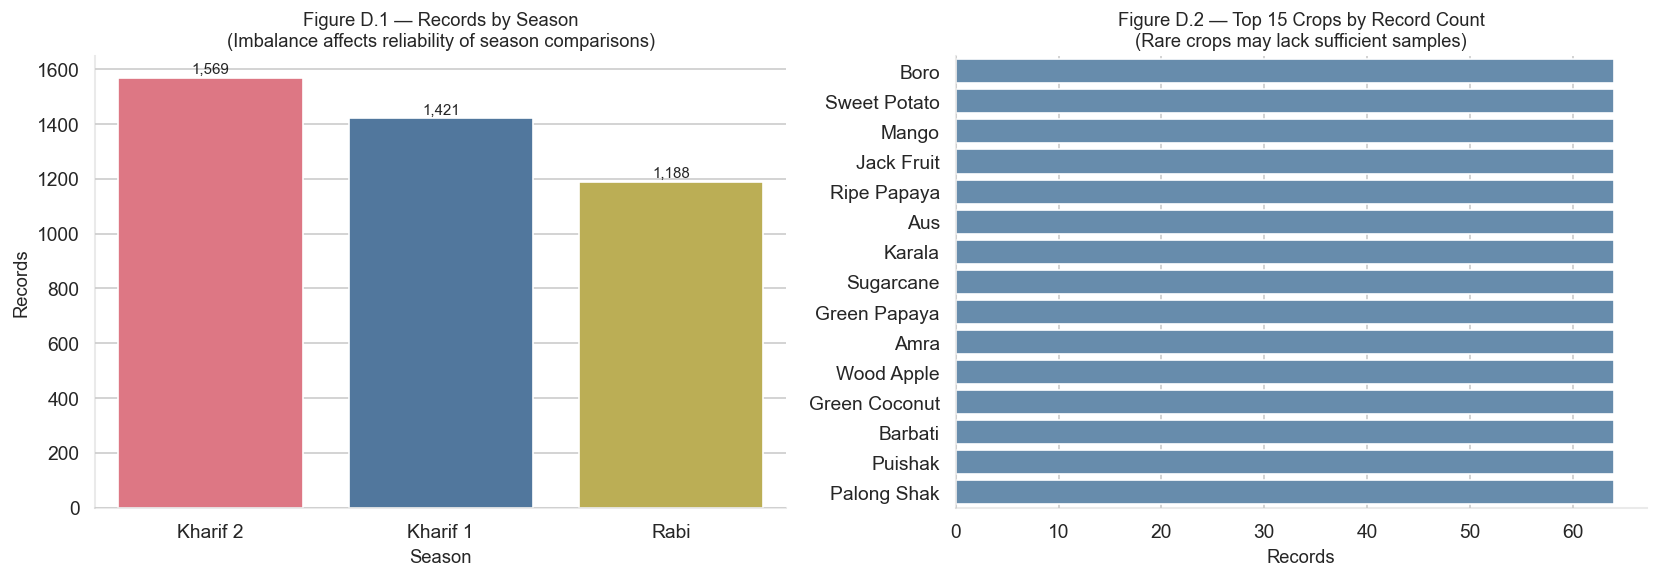

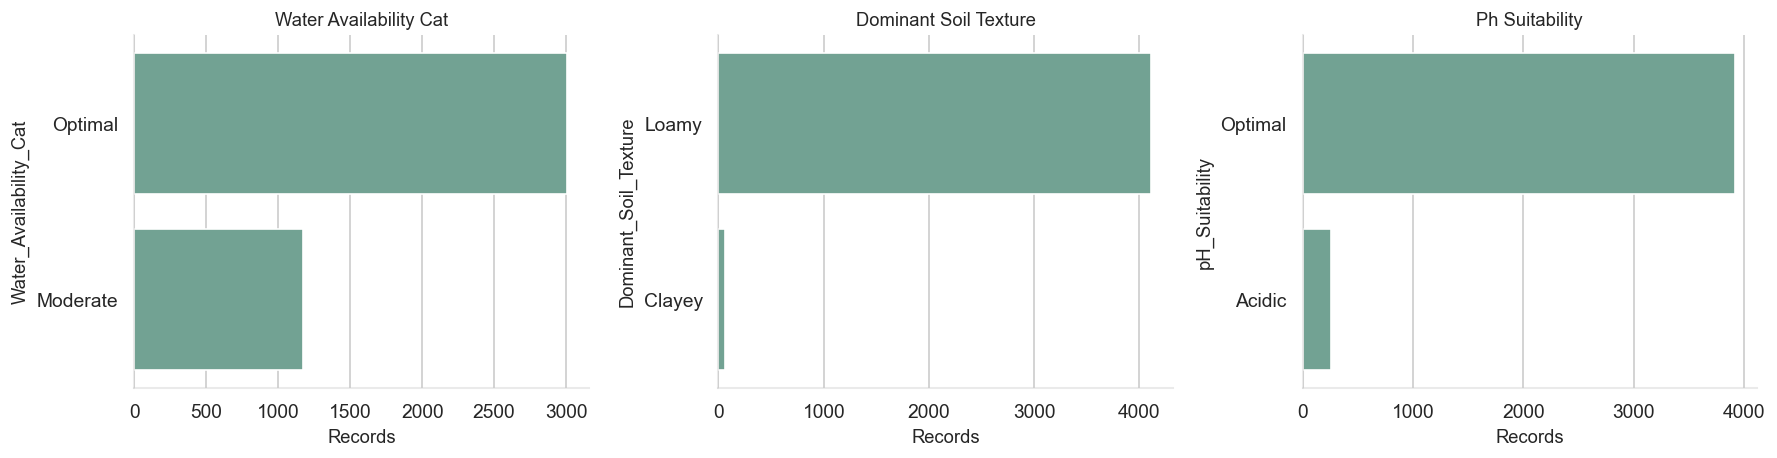


─── Coverage Summary ───
  Season                       |   3 unique | dominant = 'Kharif 2' (37.6%)
  Crop Name                    |  72 unique | dominant = 'Boro' (1.5%)
  District                     |  64 unique | dominant = 'Thakurgaon' (1.7%)
  Water_Availability_Cat       |   2 unique | dominant = 'Optimal' (72.0%)
  Dominant_Soil_Texture        |   2 unique | dominant = 'Loamy' (98.4%)


In [5]:
# ============================================================
# SECTION D — Dataset Coverage & Categorical Overview
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# D.1 Season record count
if require_cols(["Season"], "D.1", df):
    pal   = season_palette(df["Season"])
    order = df["Season"].value_counts().index
    sns.countplot(data=df, x="Season", order=order, palette=pal, ax=axes[0])
    for bar in axes[0].patches:
        h = bar.get_height()
        if h > 0:
            axes[0].text(bar.get_x()+bar.get_width()/2, h+5, f"{int(h):,}",
                         ha="center", va="bottom", fontsize=9)
    axes[0].set_title("Figure D.1 — Records by Season\n(Imbalance affects reliability of season comparisons)", fontsize=11)
    axes[0].set_xlabel("Season"); axes[0].set_ylabel("Records"); despine(axes[0])

# D.2 Top 15 crops
if require_cols(["Crop Name"], "D.2", df):
    tc = df["Crop Name"].value_counts().head(15)
    sns.barplot(x=tc.values, y=tc.index, ax=axes[1], color="#5b8db8")
    axes[1].set_title("Figure D.2 — Top 15 Crops by Record Count\n(Rare crops may lack sufficient samples)", fontsize=11)
    axes[1].set_xlabel("Records"); axes[1].set_ylabel(""); despine(axes[1])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"fig_D_coverage.png"), dpi=300, bbox_inches="tight")
plt.show()

# D.3 Additional categorical breakdowns
cat_extras = [c for c in ["Water_Availability_Cat","Dominant_Soil_Texture","pH_Suitability"] if c in df.columns]
if cat_extras:
    fig, axes = plt.subplots(1, len(cat_extras), figsize=(5*len(cat_extras), 4))
    if len(cat_extras)==1: axes=[axes]
    for ax, col in zip(axes, cat_extras):
        vc = df[col].value_counts()
        sns.barplot(x=vc.values, y=vc.index, ax=ax, color="#6aaa96")
        ax.set_title(f"{pretty(col)}", fontsize=11); ax.set_xlabel("Records"); despine(ax)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"fig_D_categorical.png"), dpi=300, bbox_inches="tight")
    plt.show()

print("\n─── Coverage Summary ───")
for col in ["Season","Crop Name","District","Water_Availability_Cat","Dominant_Soil_Texture"]:
    if col in df.columns:
        top_v = df[col].value_counts(normalize=True).head(1)
        print(f"  {col:<28s} | {df[col].nunique():>3} unique | dominant = '{top_v.index[0]}' ({top_v.values[0]:.1%})")


## Section E — Univariate Distributions

**Objective:** Examine shape, range, and skewness of key numeric variables. `get_plot_col()` automatically selects the log-transformed version for highly skewed columns, ensuring the axis label reflects the transformation.


─── Skewness summary for key variables ───
Area                  7.940233
Production            7.490667
Yield                 5.175119
Calc_Yield            5.175119
Heat_Stress_Days      1.100677
Nitrogen              1.017127
Organic_Carbon        0.823146
Rainfall              0.431658
Avg_Salinity_Index    0.201988
Soil_Moisture_mm     -0.153349
Avg Temp             -0.184812
NDVI_Season_Mean     -0.346360



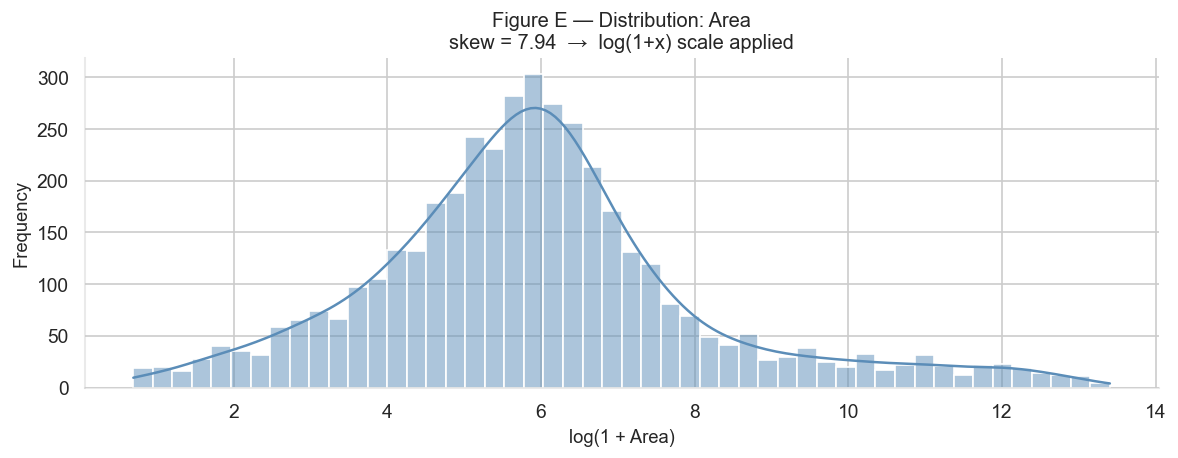

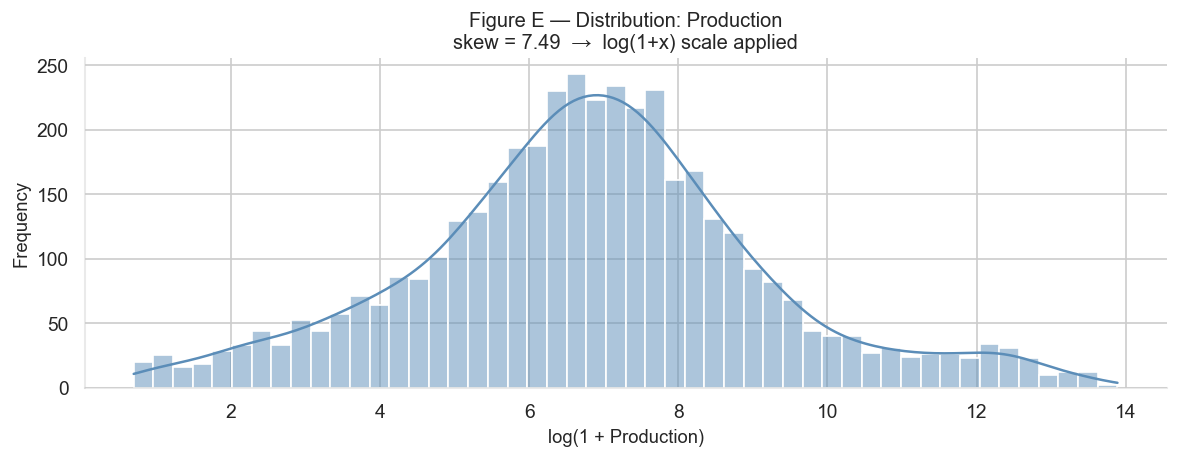

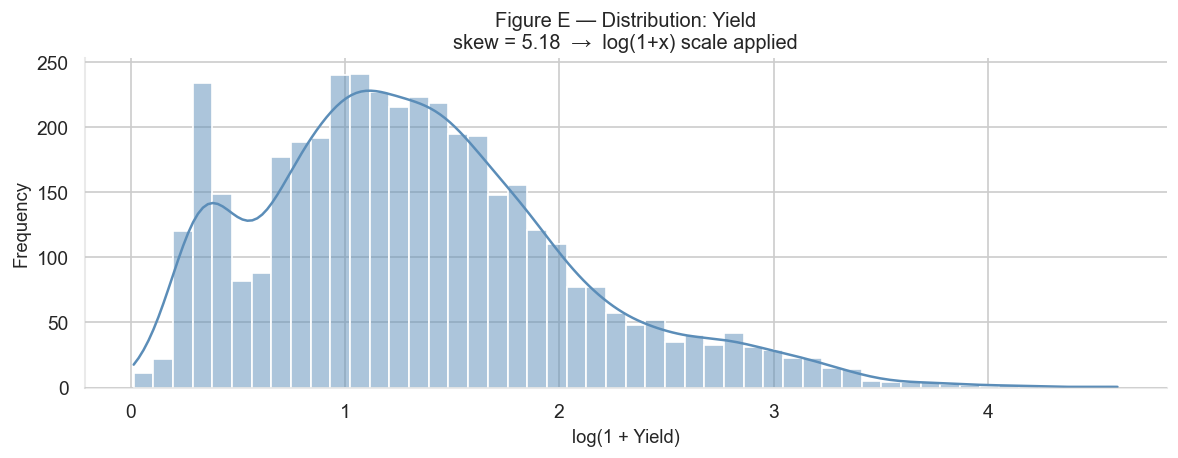

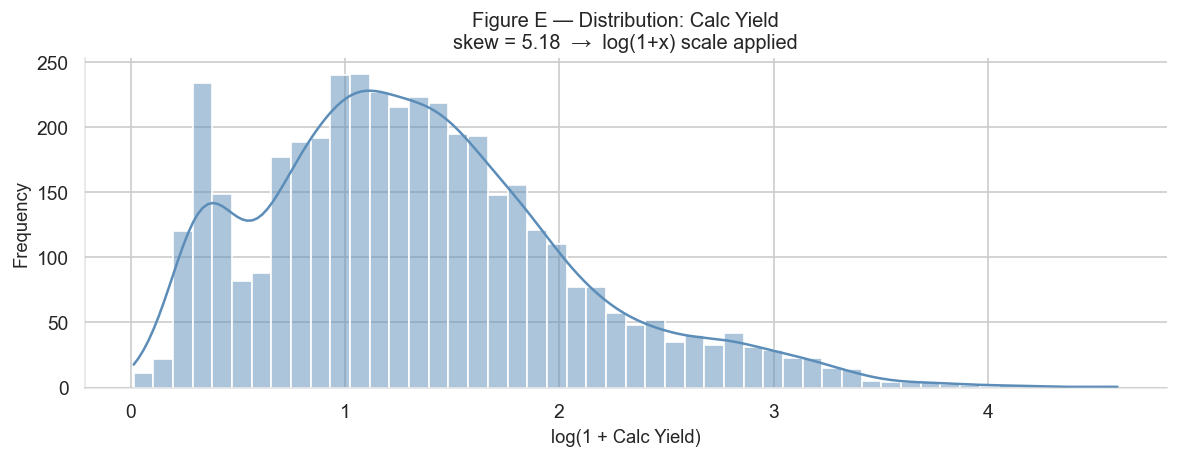

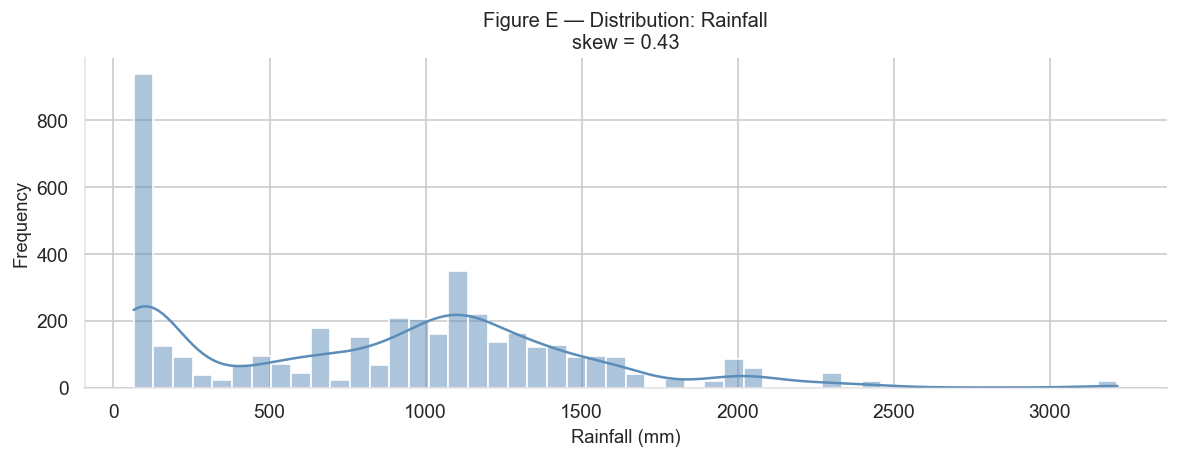

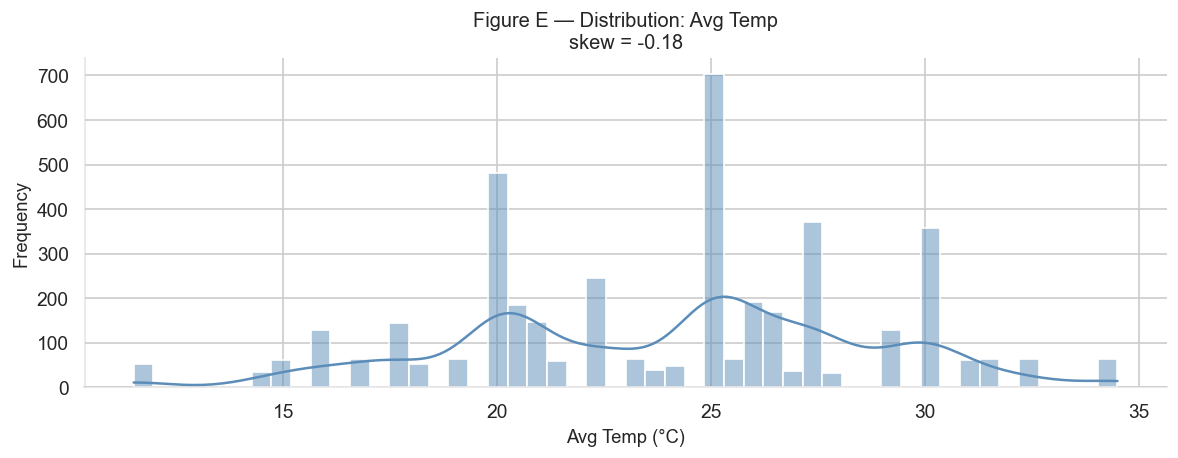

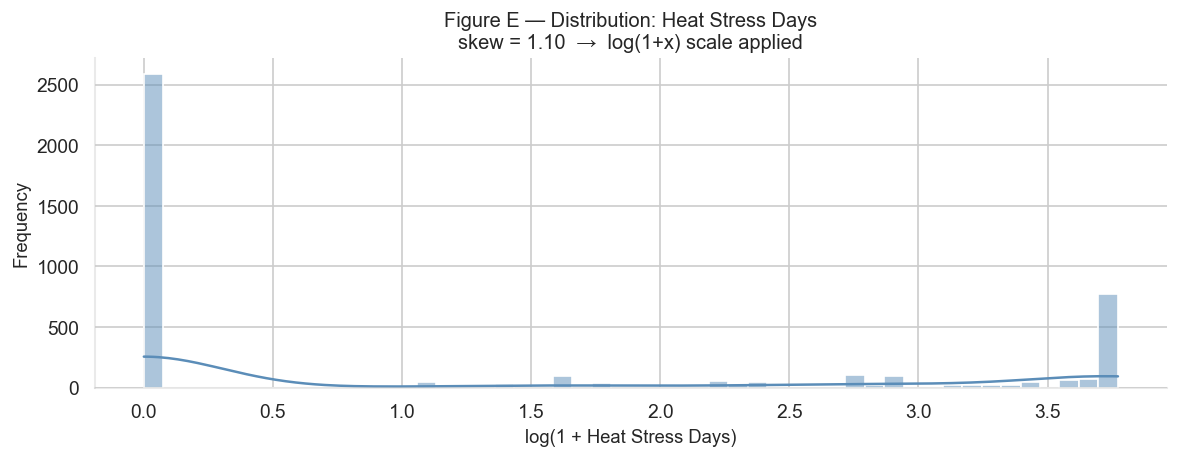

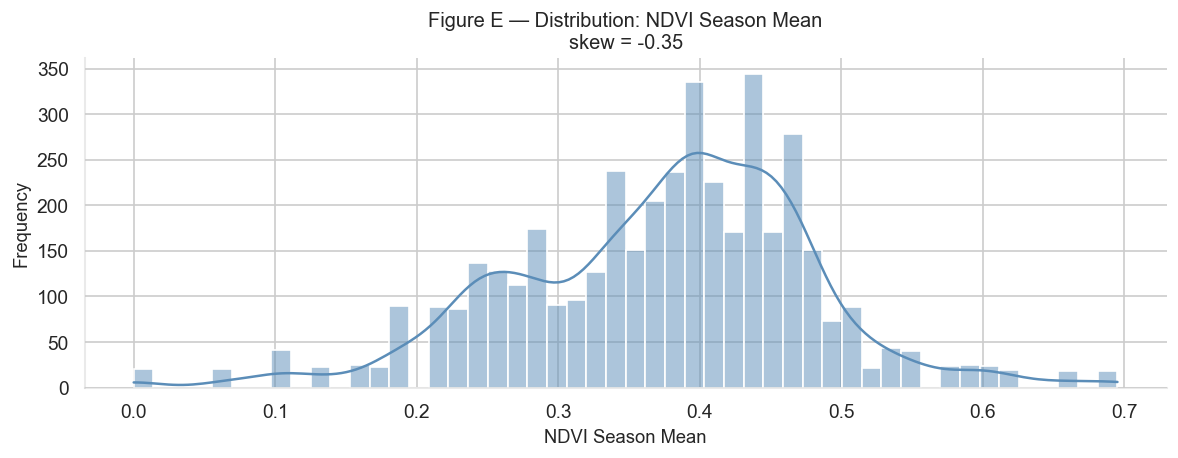

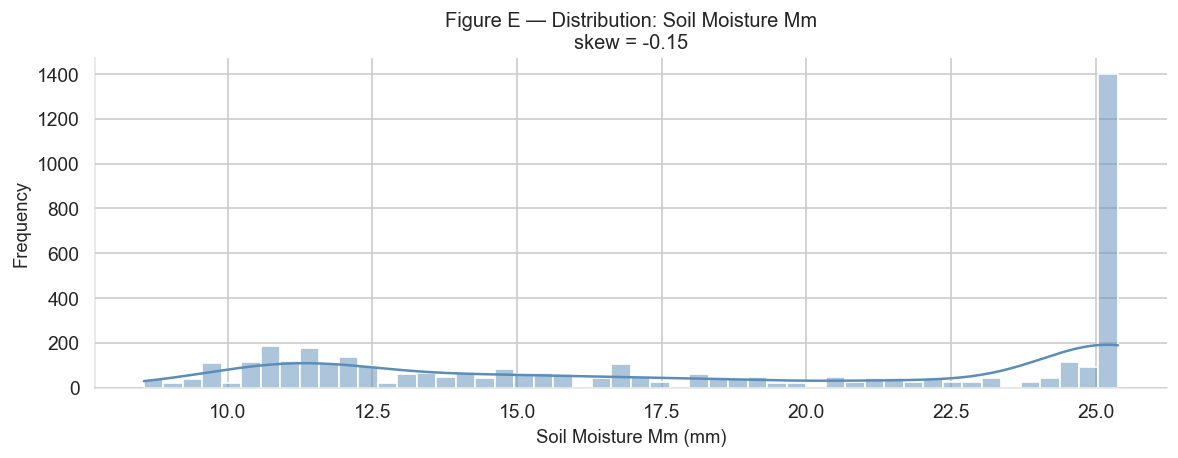

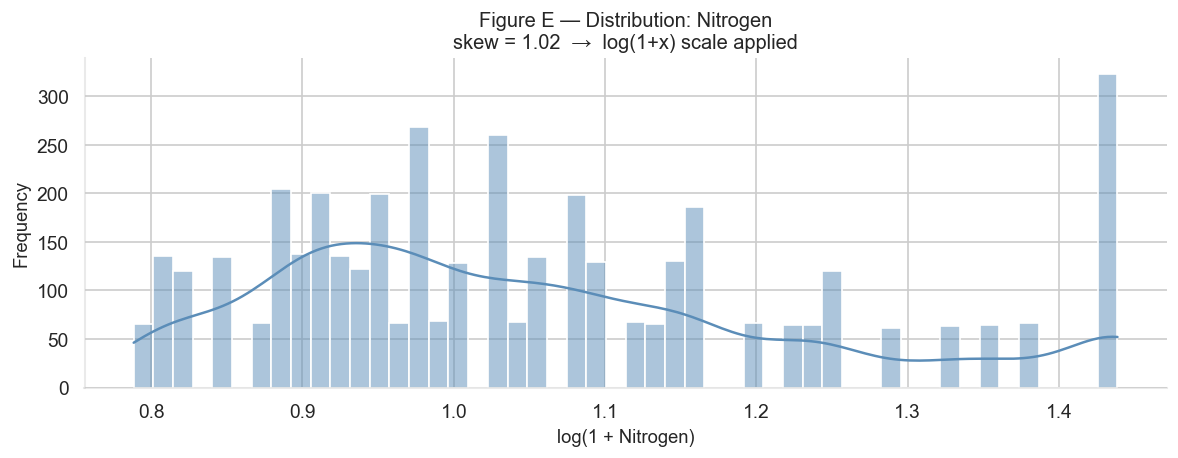

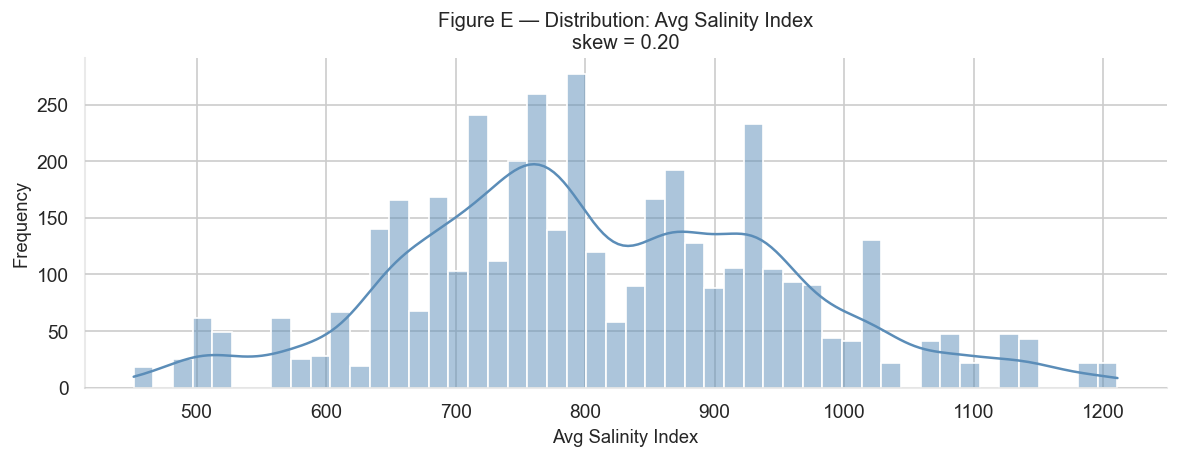

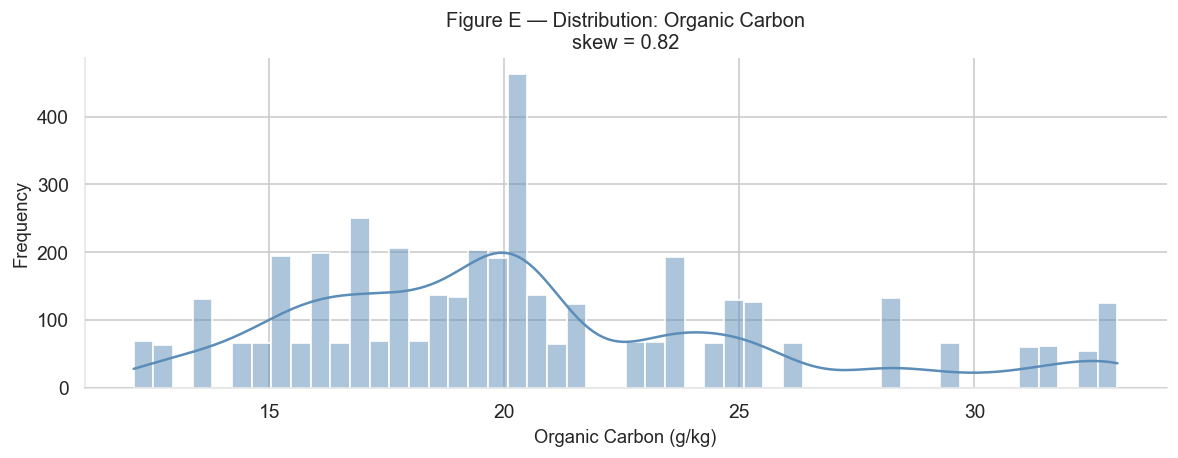

In [6]:
# ============================================================
# SECTION E — Univariate Distributions
# ============================================================
# get_plot_col() automatically selects the log column when |skew| >= 1.0.
# All axis labels correctly reflect whether raw or log scale is displayed.

FOCUS_VARS = [c for c in [
    "Area","Production","Yield","Calc_Yield",
    "Rainfall","Avg Temp","Heat_Stress_Days",
    "NDVI_Season_Mean","Soil_Moisture_mm",
    "Nitrogen","Avg_Salinity_Index","Organic_Carbon"
] if c in df.columns]

skew_vals = df[FOCUS_VARS].skew(numeric_only=True)
print("─── Skewness summary for key variables ───")
print(skew_vals.sort_values(ascending=False).to_string())
print()

for col in FOCUS_VARS:
    plot_col  = get_plot_col(col)
    skew_v    = skew_vals.get(col, 0)
    is_log    = plot_col != col
    x_label   = f"log(1 + {pretty(col)})" if is_log else axis_label(col)

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(df[plot_col].dropna(), bins=50, kde=True, ax=ax,
                 color="#5b8db8", line_kws={"lw":1.5})
    ax.set_title(
        f"Figure E — Distribution: {pretty(col)}\n"
        f"skew = {skew_v:.2f}{'  →  log(1+x) scale applied' if is_log else ''}",
        fontsize=12)
    ax.set_xlabel(x_label); ax.set_ylabel("Frequency")
    if not is_log and col in {"Production","Area"}:
        ax.xaxis.set_major_formatter(FuncFormatter(fmt_thousands))
    despine(ax); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,f"fig_E_{col.replace(' ','_')}.png"), dpi=300, bbox_inches="tight")
    plt.show()


## Section F — Season & Crop Group Effects

**Objective:** Compare Production and Yield distributions across Season and Crop dimensions.

Violin plots reveal full distribution shape (including bimodality) that boxplots compress. Charts are faceted by soil texture in F.3 to answer: *which soil types host the highest-yield crops?*


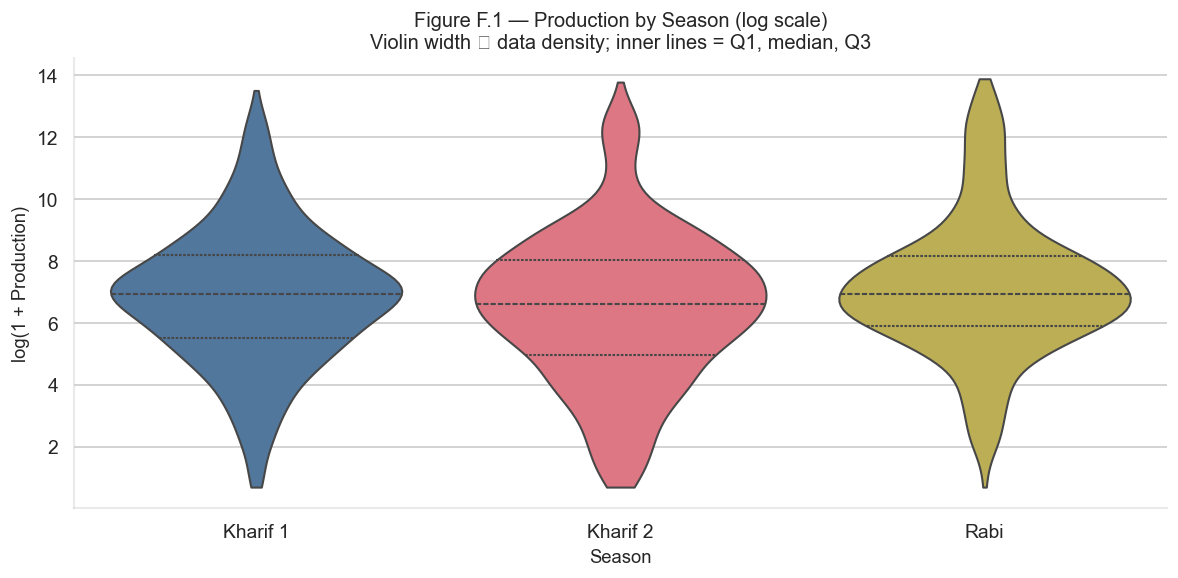

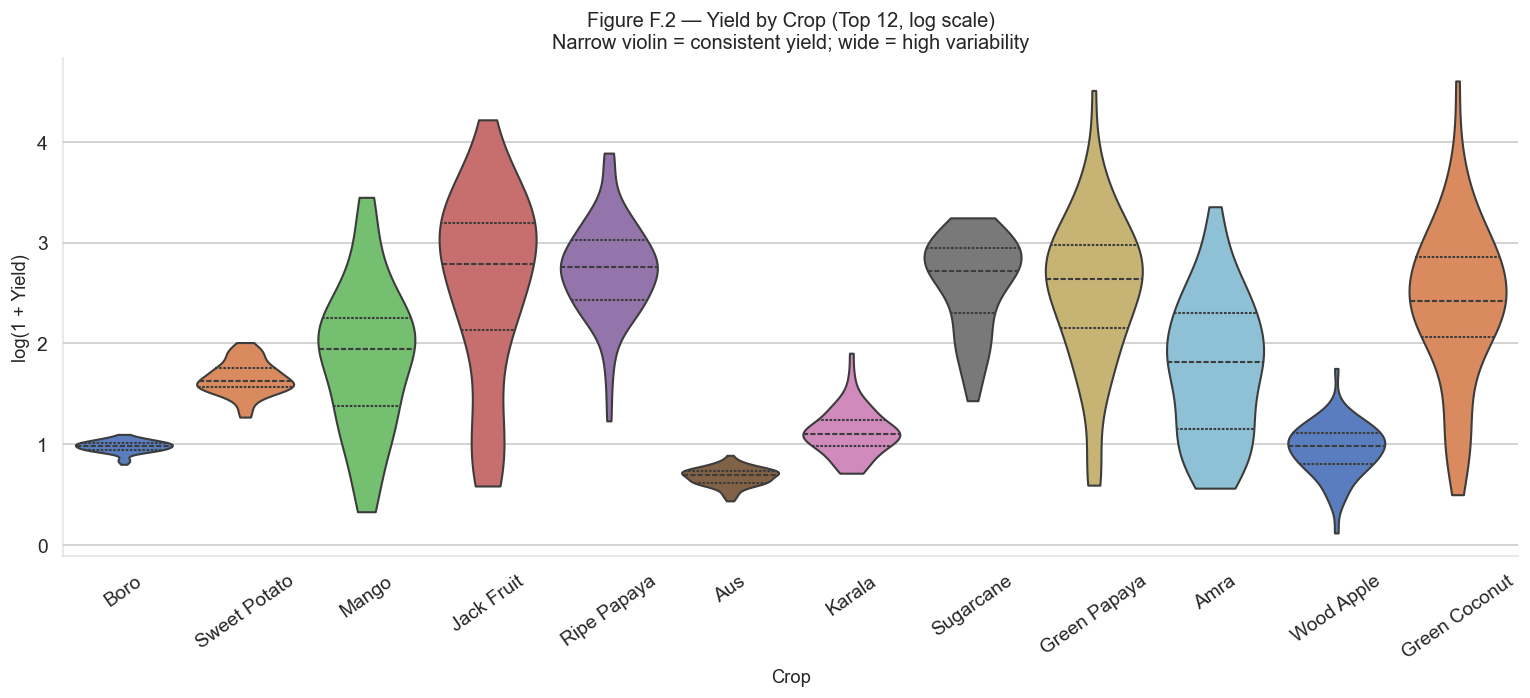

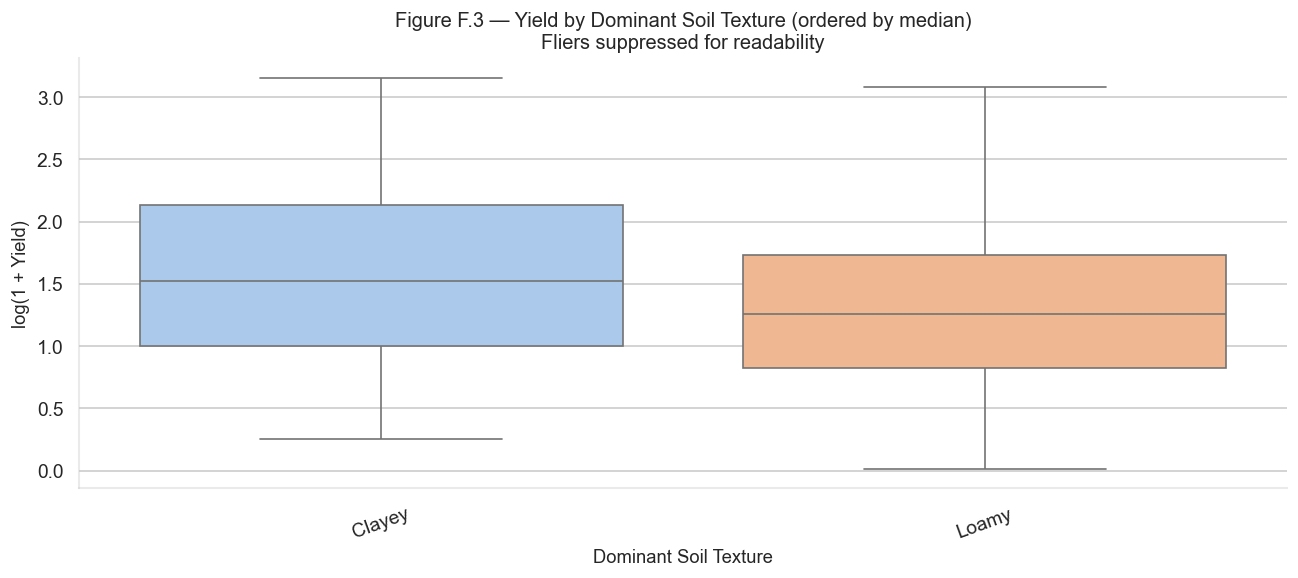

In [7]:
# ============================================================
# SECTION F — Season & Crop Effects on Output
# ============================================================

LOG_YIELD = get_plot_col("Yield") if "Yield" in df.columns else get_plot_col("Calc_Yield")
LOG_PROD  = get_plot_col("Production")
Y_YIELD   = f"log(1 + Yield)" if LOG_YIELD.startswith("log") else axis_label("Yield")
Y_PROD    = f"log(1 + Production)" if LOG_PROD.startswith("log") else axis_label("Production")

# F.1 Production by Season
if require_cols(["Season", LOG_PROD], "F.1", df):
    pal   = season_palette(df["Season"])
    order = [s for s in ["Kharif 1","Kharif 2","Rabi"] if s in df["Season"].unique()]
    order += [s for s in df["Season"].unique() if s not in {"Kharif 1","Kharif 2","Rabi"}]
    fig, ax = plt.subplots(figsize=(10,5))
    sns.violinplot(data=df, x="Season", y=LOG_PROD, order=order,
                   hue="Season", palette=pal, legend=False,
                   cut=0, inner="quartile", dodge=False, ax=ax)
    ax.set_title("Figure F.1 — Production by Season (log scale)\n"
                 "Violin width ∝ data density; inner lines = Q1, median, Q3", fontsize=12)
    ax.set_xlabel("Season"); ax.set_ylabel(Y_PROD); despine(ax)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_F1.png"),dpi=300,bbox_inches="tight"); plt.show()

# F.2 Yield by top crops
if require_cols(["Crop Name", LOG_YIELD], "F.2", df):
    top_crops = df["Crop Name"].value_counts().head(12).index
    sub = df[df["Crop Name"].isin(top_crops)].copy()
    fig, ax = plt.subplots(figsize=(13,6))
    sns.violinplot(data=sub, x="Crop Name", y=LOG_YIELD,
                   cut=0, inner="quartile", palette="muted", ax=ax)
    ax.set_title("Figure F.2 — Yield by Crop (Top 12, log scale)\n"
                 "Narrow violin = consistent yield; wide = high variability", fontsize=12)
    ax.set_xlabel("Crop"); ax.set_ylabel(Y_YIELD)
    ax.tick_params(axis="x", rotation=35); despine(ax)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_F2.png"),dpi=300,bbox_inches="tight"); plt.show()

# F.3 Yield by Soil Texture
if require_cols(["Dominant_Soil_Texture", LOG_YIELD], "F.3", df):
    order_soil = df.groupby("Dominant_Soil_Texture")[LOG_YIELD].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(11,5))
    sns.boxplot(data=df, x="Dominant_Soil_Texture", y=LOG_YIELD,
                order=order_soil, palette="pastel", showfliers=False, ax=ax)
    ax.set_title("Figure F.3 — Yield by Dominant Soil Texture (ordered by median)\n"
                 "Fliers suppressed for readability", fontsize=12)
    ax.set_xlabel("Dominant Soil Texture"); ax.set_ylabel(Y_YIELD)
    ax.tick_params(axis="x", rotation=20); despine(ax)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_F3.png"),dpi=300,bbox_inches="tight"); plt.show()


## Section G — Bivariate Relationships with Insight Annotations

**Objective:** Explore driver → output associations with two improvements over standard scatter/hexbin charts:

1. **OLS regression line** on hexbin plots to summarize marginal trends.
2. **Annotation layer** — outlier districts (e.g., high yield despite low rainfall) are flagged directly on the chart with callout arrows, turning a visual observation into a named insight.

> The annotations follow the *Cairo principle*: every mark on a chart should carry information. Points annotated here represent *interesting exceptions to the trend* that warrant follow-up investigation.


In [ ]:
# ============================================================
# SECTION G — Bivariate Relationships with Insight Annotations
# ============================================================

TARGET_Y = LOG_YIELD

def hexbin_annotated(x_col, y_col, label=None, gridsize=40,
                     annotate_extreme=True, n_annotate=3):
    """
    Hexbin density + OLS trend line.
    Optionally annotates top-N outlier districts (highest y residual from OLS).
    """
    if not require_cols([x_col, y_col], f"G — {x_col} vs {y_col}", df):
        return
    sub = df[[x_col, y_col] + (["District"] if "District" in df.columns else [])].dropna()
    x_v, y_v = sub[x_col].to_numpy(), sub[y_col].to_numpy()

    fig, ax = plt.subplots(figsize=(10,5))
    hb = ax.hexbin(x_v, y_v, gridsize=gridsize, mincnt=1, cmap="YlOrRd")
    cb = fig.colorbar(hb, ax=ax, pad=0.02); cb.set_label("Point density")

    # OLS trend
    coeffs = np.polyfit(x_v, y_v, 1)
    x_rng  = np.linspace(x_v.min(), x_v.max(), 200)
    ax.plot(x_rng, np.polyval(coeffs, x_rng), color="#2c3e50",
            lw=2, ls="--", label=f"OLS  slope = {coeffs[0]:.3f}")
    ax.legend(frameon=False, fontsize=9)

    # Annotate top-N residual outliers (most interesting exceptions)
    if annotate_extreme and "District" in sub.columns and len(sub) > 10:
        sub["_resid"] = y_v - np.polyval(coeffs, x_v)
        # High-positive residuals: performs better than trend predicts
        top_pos = sub.nlargest(n_annotate, "_resid")
        for _, row in top_pos.iterrows():
            ax.annotate(
                f"↑ {row['District']}",
                xy=(row[x_col], row[y_col]),
                xytext=(row[x_col] + (x_v.max()-x_v.min())*0.06, row[y_col]),
                fontsize=7.5, color="#1a5276",
                arrowprops=dict(arrowstyle="->", color="#1a5276", lw=0.8),
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="none")
            )
        # High-negative residuals: underperforms vs. trend
        top_neg = sub.nsmallest(n_annotate, "_resid")
        for _, row in top_neg.iterrows():
            ax.annotate(
                f"↓ {row['District']}",
                xy=(row[x_col], row[y_col]),
                xytext=(row[x_col] - (x_v.max()-x_v.min())*0.12, row[y_col]),
                fontsize=7.5, color="#922b21",
                arrowprops=dict(arrowstyle="->", color="#922b21", lw=0.8),
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, ec="none")
            )

    x_lbl = f"log(1+{pretty(x_col)})" if x_col.startswith("log_") else axis_label(x_col)
    y_lbl = f"log(1+Yield)" if y_col.startswith("log_") else axis_label(y_col)
    ax.set_title(
        f"Figure G — {label or pretty(x_col)} vs. Yield\n"
        f"Arrows mark districts that over/under-perform relative to the OLS trend",
        fontsize=12)
    ax.set_xlabel(x_lbl); ax.set_ylabel(y_lbl); despine(ax)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,f"fig_G_{x_col.replace(' ','_')}.png"),dpi=300,bbox_inches="tight")
    plt.show()

for x_col, lbl in [
    ("NDVI_Season_Mean", "Vegetation Index (NDVI)"),
    ("Rainfall",         "Seasonal Rainfall"),
    ("Avg Temp",         "Average Temperature"),
    ("Heat_Stress_Days", "Heat Stress Days"),
    ("Soil_Moisture_mm", "Soil Moisture"),
]:
    hexbin_annotated(x_col, TARGET_Y, label=lbl)


## Section H — Heat Stress Threshold Analysis with Reference Lines

**Objective:** Frame heat stress as an *actionable decision variable* by visualizing the yield impact at the 75th-percentile threshold.

**Insight annotations added:**
- Vertical reference line at the 75th percentile of Heat Stress Days.
- Horizontal reference line at the overall median yield (biological baseline).
- Annotation callout explaining each line's agronomic significance.

> **Critical temperature context:** Optimal rice growing temperature is typically 25–30 °C; above 35 °C for extended periods causes spikelet sterility. Reference lines make this domain knowledge explicit in the visualization rather than relying on text footnotes.


In [ ]:
# ============================================================
# SECTION H — Heat Stress Threshold with Biological Reference Lines
# ============================================================

if not require_cols(["Heat_Stress_Days"], "H", df):
    pass
else:
    LOG_Y = LOG_YIELD

    # H.1 Scatter with threshold reference lines
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # ── H.1a  Scatter: Heat Stress Days vs Yield (with reference lines) ───────
    if LOG_Y in df.columns:
        ax = axes[0]
        thresh_hs = df["Heat_Stress_Days"].quantile(0.75)
        thresh_y  = df[LOG_Y].median()

        # Thin scatter (transparent)
        ax.scatter(df["Heat_Stress_Days"], df[LOG_Y],
                   alpha=0.12, s=12, color="#5b8db8", linewidth=0)

        # Reference line — Heat Stress threshold
        ax.axvline(thresh_hs, color="#e74c3c", lw=2, ls="--", zorder=5)
        ax.annotate(
            f"Risk threshold\n(75th pct = {thresh_hs:.0f} days)",
            xy=(thresh_hs, ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else df[LOG_Y].max()),
            xytext=(thresh_hs + df["Heat_Stress_Days"].std()*0.5,
                    df[LOG_Y].quantile(0.85)),
            fontsize=8, color="#c0392b", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2),
        )

        # Reference line — median yield baseline
        ax.axhline(thresh_y, color="#27ae60", lw=1.5, ls=":", zorder=4)
        ax.annotate(
            f"Median yield baseline ({thresh_y:.2f})",
            xy=(df["Heat_Stress_Days"].min(), thresh_y),
            xytext=(df["Heat_Stress_Days"].min() + 1, thresh_y + df[LOG_Y].std()*0.25),
            fontsize=8, color="#1e8449",
            arrowprops=dict(arrowstyle="->", color="#1e8449", lw=0.9),
        )

        ax.set_title("Figure H.1a — Yield vs. Heat Stress Days\n"
                     "Red line = 75th pct threshold; green = median yield baseline", fontsize=11)
        ax.set_xlabel(axis_label("Heat_Stress_Days"))
        ax.set_ylabel("log(1 + Yield)"); despine(ax)

    # ── H.1b  Box: high vs. low stress groups ────────────────────────────────
    if LOG_Y in df.columns:
        ax = axes[1]
        thresh_hs = df["Heat_Stress_Days"].quantile(0.75)
        sub = df[["Heat_Stress_Days", LOG_Y]].dropna().copy()
        sub["Stress Group"] = np.where(sub["Heat_Stress_Days"] > thresh_hs,
                                       f"High Stress (>{thresh_hs:.0f} d)",
                                       f"Normal (≤{thresh_hs:.0f} d)")
        order_g = [f"Normal (≤{thresh_hs:.0f} d)", f"High Stress (>{thresh_hs:.0f} d)"]
        sns.boxplot(data=sub, x="Stress Group", y=LOG_Y, order=order_g,
                    palette=["#27ae60","#e74c3c"], showfliers=False, ax=ax)

        # Annotate median difference
        med_low  = sub[sub["Stress Group"]==order_g[0]][LOG_Y].median()
        med_high = sub[sub["Stress Group"]==order_g[1]][LOG_Y].median()
        ax.annotate(f"Δ median = {med_high-med_low:+.2f} log-units",
                    xy=(0.5, (med_low+med_high)/2),
                    xycoords=("axes fraction","data"),
                    ha="center", fontsize=9, color="#555",
                    bbox=dict(boxstyle="round,pad=0.3",fc="lightyellow",ec="none",alpha=0.9))

        # Critical temperature annotation
        ax.annotate("⚠  Above ~35 °C for sustained periods\ncauses spikelet sterility in rice",
                    xy=(1, med_high), xycoords=("axes fraction","data"),
                    xytext=(0.72, 0.92), textcoords="axes fraction",
                    fontsize=8, color="#7d3c98", style="italic",
                    arrowprops=dict(arrowstyle="->", color="#7d3c98", lw=0.8))

        ax.set_title("Figure H.1b — Yield Distribution by Heat Stress Group\n"
                     "(Annotation shows median shift; biological limit referenced)", fontsize=11)
        ax.set_xlabel(""); ax.set_ylabel("log(1 + Yield)"); despine(ax)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"fig_H_heat_stress.png"),dpi=300,bbox_inches="tight")
    plt.show()

    # H.2 Extreme Heat Risk categories
    if require_cols(["Extreme_Heat_Risk", LOG_Y], "H.2", df):
        risk_order = df.groupby("Extreme_Heat_Risk")[LOG_Y].median().sort_values(ascending=False).index
        pal_risk = {k: {"Low Risk":"#27ae60","Moderate Risk":"#f39c12",
                        "Medium Risk":"#f39c12","High Risk":"#e74c3c"}.get(k,"#7f7f7f")
                    for k in risk_order}
        fig, ax = plt.subplots(figsize=(9,5))
        sns.boxplot(data=df, x="Extreme_Heat_Risk", y=LOG_Y,
                    order=risk_order, palette=pal_risk, showfliers=False, ax=ax)
        ax.set_title("Figure H.2 — Yield by Extreme Heat Risk Category\n"
                     "Ordered by median yield; fliers suppressed", fontsize=12)
        ax.set_xlabel("Heat Risk Category"); ax.set_ylabel("log(1 + Yield)")
        ax.tick_params(axis="x", rotation=15); despine(ax)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR,"fig_H2_heat_risk.png"),dpi=300,bbox_inches="tight"); plt.show()


## Section I — District-Level Performance Analysis

Two complementary rankings prevent conflating *efficiency* (Yield per ha) with *scale* (total output). The stacked bar chart additionally shows seasonal composition per district.


In [ ]:
# ============================================================
# SECTION I — District-Level Performance
# ============================================================

YIELD_COL = "Yield" if "Yield" in df.columns else ("Calc_Yield" if "Calc_Yield" in df.columns else None)

if require_cols(["District"] + ([YIELD_COL] if YIELD_COL else []), "I", df):

    # I.1 Mean Yield — lollipop
    top_n_y = 25
    mean_y = df.groupby("District")[YIELD_COL].mean().sort_values(ascending=False).head(top_n_y).sort_values()
    fig, ax = plt.subplots(figsize=(10,9))
    ax.scatter(mean_y.values, range(len(mean_y)), s=65, color="#2c7bb6", zorder=3)
    for i,v in enumerate(mean_y.values): ax.plot([0,v],[i,i],color="#aaa",lw=1.2,zorder=2)
    ax.set_yticks(range(len(mean_y))); ax.set_yticklabels(mean_y.index, fontsize=9)
    ax.set_title(f"Figure I.1 — Top {top_n_y} Districts by Mean Yield\n(Efficiency metric — independent of cultivated area size)",fontsize=12)
    ax.set_xlabel(axis_label(YIELD_COL)); despine(ax)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_I1.png"),dpi=300,bbox_inches="tight"); plt.show()

    # I.2 Total Production — lollipop
    top_n_p = 20
    tot_p = df.groupby("District")["Production"].sum().sort_values(ascending=False).head(top_n_p).sort_values()
    fig, ax = plt.subplots(figsize=(10,8))
    ax.scatter(tot_p.values, range(len(tot_p)), s=65, color="#d7191c", zorder=3)
    for i,v in enumerate(tot_p.values): ax.plot([0,v],[i,i],color="#aaa",lw=1.2,zorder=2)
    ax.set_yticks(range(len(tot_p))); ax.set_yticklabels(tot_p.index, fontsize=9)
    ax.set_title(f"Figure I.2 — Top {top_n_p} Districts by Total Production\n(Volume metric — compare with Figure I.1 to spot efficiency gaps)",fontsize=12)
    ax.set_xlabel(axis_label("Production")); ax.xaxis.set_major_formatter(FuncFormatter(fmt_thousands)); despine(ax)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_I2.png"),dpi=300,bbox_inches="tight"); plt.show()

    # I.3 Stacked bar by Season
    if require_cols(["Season"], "I.3", df):
        top_d = df.groupby("District")["Production"].sum().sort_values(ascending=False).head(12).index
        pivot = df[df["District"].isin(top_d)].pivot_table(
            index="District",columns="Season",values="Production",aggfunc="sum",fill_value=0).loc[top_d]
        pal = season_palette(df["Season"])
        fig, ax = plt.subplots(figsize=(13,6))
        bottom = np.zeros(len(pivot))
        for s in pivot.columns:
            ax.bar(pivot.index, pivot[s].values, bottom=bottom, label=s,
                   color=pal.get(s,"#7f7f7f"), edgecolor="white", lw=0.5)
            bottom += pivot[s].values
        ax.set_title("Figure I.3 — Production Composition by Season (Top 12 Districts)\nStacked bars reveal which season drives each district",fontsize=12)
        ax.set_xlabel("District"); ax.set_ylabel(axis_label("Production"))
        ax.tick_params(axis="x",rotation=25)
        ax.legend(title="Season",frameon=False,bbox_to_anchor=(1.02,1),loc="upper left")
        ax.yaxis.set_major_formatter(FuncFormatter(fmt_thousands)); despine(ax)
        plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_I3.png"),dpi=300,bbox_inches="tight"); plt.show()


## Section J — District × Season Production Heatmap

**Readability enhancement:** Annotations are suppressed when the number of districts exceeds 20 (cell size too small for readable numbers). For large heatmaps, color alone conveys the pattern.


In [ ]:
# ============================================================
# SECTION J — District × Season Heatmap (readability controls)
# ============================================================
# Annotation rule: show numbers only when top_d <= 20 (cells large enough).
# For larger grids, color gradient conveys the pattern without text clutter.

if require_cols(["District","Season"], "J", df):
    TOP_D = 15
    top_d = df.groupby("District")["Production"].sum().sort_values(ascending=False).head(TOP_D).index
    piv = df[df["District"].isin(top_d)].pivot_table(
        index="District", columns="Season", values="Production", aggfunc="sum", fill_value=0)

    SHOW_ANNOT = TOP_D <= 20   # suppress annotations for crowded grids
    ANNOT_DATA = piv.applymap(lambda v: f"{v/1e3:.0f}k" if v >= 1000 else str(int(v))) if SHOW_ANNOT else False

    fig, ax = plt.subplots(figsize=(11,7))
    sns.heatmap(piv, ax=ax, cmap="YlGnBu", linewidths=0.4,
                annot=ANNOT_DATA, fmt="", annot_kws={"size":8} if SHOW_ANNOT else {},
                cbar_kws={"label":"Total Production (metric tons)"})
    ax.set_title(
        f"Figure J — District × Season Production Heatmap  (Top {TOP_D} districts)\n"
        "Single-column dominance = season dependency; uniform rows = diversified production",
        fontsize=12)
    ax.set_xlabel("Season"); ax.set_ylabel("District"); despine(ax)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_J_heatmap.png"),dpi=300,bbox_inches="tight"); plt.show()


## Section K — Correlation Analysis

**Enhancement:** A small-correlation mask (`|r| < 0.10`) is applied to the full heatmap, removing visual noise from near-zero associations. Only meaningful correlations (positive or negative) are colored; weak ones appear as blank cells.


In [ ]:
# ============================================================
# SECTION K — Correlation Heatmap with Small-r Suppression
# ============================================================
# Two masks are applied:
#   1. Upper triangle mask  — prevents redundant mirroring
#   2. Small-r mask (|r| < R_THRESH) — suppresses near-zero noise to reduce visual clutter

R_THRESH = 0.10   # correlations weaker than ±0.10 are blanked out

num = df.select_dtypes(include=[np.number]).copy()
for raw in ("Production","Calc_Yield","Yield","Area"):
    if raw in num.columns and f"log_{raw}" in num.columns:
        num.drop(columns=[raw], inplace=True)
binary_cols = [c for c in num.columns if num[c].nunique() <= 2]
num.drop(columns=binary_cols, inplace=True, errors="ignore")

corr = num.corr()
mask_upper = np.triu(np.ones_like(corr, dtype=bool))
mask_small = corr.abs() < R_THRESH
mask_combined = mask_upper | mask_small

# K.1 Full (small-r suppressed)
fig, ax = plt.subplots(figsize=(15,12))
annot_arr = corr.copy()
annot_arr[mask_combined] = np.nan
sns.heatmap(corr, mask=mask_combined, cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.3, cbar_kws={"label":"Pearson r","shrink":0.8}, ax=ax)
ax.set_title(f"Figure K.1 — Pearson Correlation Matrix\n"
             f"Upper triangle masked; |r| < {R_THRESH} cells blanked to reduce visual noise",
             fontsize=13)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_K1_corr.png"),dpi=300,bbox_inches="tight"); plt.show()

# K.2 Focused on top-18 features correlated with log_Production
TARGET_CORR = "log_Production"
if TARGET_CORR in num.columns:
    top_feats = corr[TARGET_CORR].abs().sort_values(ascending=False).head(18).index.tolist()
    corr2 = num[top_feats].corr()
    mask2 = np.triu(np.ones_like(corr2,dtype=bool)) | (corr2.abs()<R_THRESH)

    fig, ax = plt.subplots(figsize=(13,11))
    sns.heatmap(corr2, mask=mask2, cmap="coolwarm", vmin=-1, vmax=1,
                annot=~mask2, fmt=".2f", annot_kws={"size":7.5},
                linewidths=0.4, cbar_kws={"label":"Pearson r"}, ax=ax)
    ax.set_title(f"Figure K.2 — Focused Correlations: Top 18 Features around {TARGET_CORR}\n"
                 "(Annotated; |r| < 0.10 blanked)", fontsize=13)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_K2_corr.png"),dpi=300,bbox_inches="tight"); plt.show()

    print("\n─── Top 10 Drivers of log_Production (Pearson r) ───")
    print(corr[TARGET_CORR].abs().sort_values(ascending=False).drop(TARGET_CORR, errors="ignore").head(10).to_string())


## Section L — Multivariate Climate Bubble Chart

Four variables encoded simultaneously: Rainfall (x), Avg Temp (y), Yield proxy (size), Extreme Heat Risk (color). Quadrant annotations provide interpretive context directly on the chart.


In [ ]:
# ============================================================
# SECTION L — Multivariate Climate Bubble Chart (Matplotlib)
# ============================================================

NEED_L = {"Rainfall","Avg Temp","Extreme_Heat_Risk"}
if require_cols(list(NEED_L), "L", df):
    Y_COL = "Yield" if "Yield" in df.columns else "Calc_Yield"
    cols  = ["Rainfall","Avg Temp", Y_COL,"Extreme_Heat_Risk"]
    pld   = df[cols].dropna().copy()

    s_raw = np.sqrt(pld[Y_COL].clip(lower=0))
    s_sc  = 30 + 250*(s_raw - s_raw.min())/(s_raw.max()-s_raw.min()+1e-9)

    risk_order = pld["Extreme_Heat_Risk"].value_counts().index.tolist()
    pal_risk   = {k: {"Low Risk":"#27ae60","Moderate Risk":"#f39c12",
                      "Medium Risk":"#f39c12","High Risk":"#e74c3c"}.get(k,"#7f7f7f")
                  for k in risk_order}

    fig, ax = plt.subplots(figsize=(11,6))
    for risk in risk_order:
        sub = pld[pld["Extreme_Heat_Risk"]==risk]
        ax.scatter(sub["Rainfall"], sub["Avg Temp"],
                   s=s_sc[pld["Extreme_Heat_Risk"]==risk],
                   color=pal_risk[risk], alpha=0.30, linewidth=0, label=risk)
    ax.legend(title="Extreme Heat Risk", frameon=False, bbox_to_anchor=(1.02,1), loc="upper left")

    # Quadrant reference lines
    x_med, y_med = pld["Rainfall"].median(), pld["Avg Temp"].median()
    ax.axvline(x_med, color="#aaa", lw=1, ls=":")
    ax.axhline(y_med, color="#aaa", lw=1, ls=":")

    # Quadrant labels
    ax_ylim = ax.get_ylim()
    ax_xlim = ax.get_xlim()
    ax.text(ax_xlim[0]+10, ax_ylim[1]*0.98,
            "Hot & Dry\n(High risk zone)", fontsize=8, color="#922b21",
            style="italic", va="top",
            bbox=dict(boxstyle="round,pad=0.3",fc="white",alpha=0.7,ec="none"))
    ax.text(ax_xlim[1]*0.72, ax_ylim[0]+0.3,
            "Cool & Wet\n(Favourable zone)", fontsize=8, color="#1e8449",
            style="italic",
            bbox=dict(boxstyle="round,pad=0.3",fc="white",alpha=0.7,ec="none"))

    ax.set_title("Figure L — Climate Map: Rainfall × Temp × Yield × Heat Risk\n"
                 "Bubble size ∝ Yield; dashed lines = medians; quadrant labels = agronomic zones",fontsize=12)
    ax.set_xlabel(axis_label("Rainfall")); ax.set_ylabel(axis_label("Avg Temp")); despine(ax)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_L_bubble.png"),dpi=300,bbox_inches="tight"); plt.show()


## Section M — Feature Importance: Impurity + Permutation + SHAP

**Objective:** Rank predictors and understand *direction* of effects using three complementary methods.

| Method | What it measures | Limitation |
|---|---|---|
| **Impurity (MDI)** | Mean node impurity decrease during training | Over-estimates high-cardinality variables |
| **Permutation** | R² drop when feature is shuffled (on test set) | Slow; correlated features split importance |
| **SHAP** | Marginal contribution of each feature per prediction | Computationally intensive; requires `pip install shap` |

**SHAP advantages over MDI/permutation:**
- Directional — distinguishes positive vs. negative effects.
- Per-sample granularity — beeswarm shows the full distribution of impact, not just mean.
- Dependence plots reveal non-linear relationships with interaction effects.


In [ ]:
# ============================================================
# SECTION M — Feature Importance: Impurity + Permutation + SHAP
# ============================================================

def cap_categories(s: pd.Series, top_k=25, other="Other"):
    keep = s.value_counts(dropna=False).head(top_k).index
    return s.where(s.isin(keep), other)

work = df.copy()
CAT_COLS = [c for c in ["Season","Crop Name","District"] if c in work.columns]
if "Crop Name" in work.columns: work["Crop Name"] = cap_categories(work["Crop Name"], 25)
if "District"  in work.columns: work["District"]  = cap_categories(work["District"],  30)

TARGET = "log_Production" if "log_Production" in work.columns else "Production"
DROP_COLS = [c for c in ["Production","log_Production","Calc_Yield","log_Calc_Yield",
                          "Yield","log_Yield","AP Ratio","Area","log_Area"]
             if c in work.columns and c != TARGET]

y_all = work[TARGET].values
X_all = work.drop(columns=DROP_COLS, errors="ignore")
X_all = pd.get_dummies(X_all, columns=CAT_COLS, drop_first=True)
X_all = (X_all.select_dtypes(include=[np.number])
               .replace([np.inf,-np.inf], np.nan)
               .fillna(X_all.select_dtypes(include=[np.number]).median(numeric_only=True)))

print(f"Feature matrix : {X_all.shape[0]:,} × {X_all.shape[1]}")
print(f"Target         : {TARGET}")

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=400, min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

pred = rf.predict(X_te)
r2   = r2_score(y_te, pred)
mae  = mean_absolute_error(y_te, pred)
rmse = mean_squared_error(y_te, pred, squared=False)
cv_r2 = cross_val_score(rf, X_all, y_all, cv=KFold(3,shuffle=True,random_state=42), scoring="r2",n_jobs=-1)
print(f"\n─── Model Evaluation ───")
print(f"  Test  R² = {r2:.4f} | MAE = {mae:.4f} | RMSE = {rmse:.4f}")
print(f"  CV R² (3-fold) = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# M.1 Impurity (MDI)
mdi = pd.Series(rf.feature_importances_, index=X_all.columns).sort_values(ascending=False).head(25)
mdi_s = mdi.sort_values()
fig, ax = plt.subplots(figsize=(10,9))
ax.scatter(mdi_s.values, range(len(mdi_s)), s=60, color="#c0392b", zorder=3)
for i,v in enumerate(mdi_s.values): ax.plot([0,v],[i,i],color="#ccc",lw=1.2,zorder=2)
ax.set_yticks(range(len(mdi_s))); ax.set_yticklabels([pretty(c) for c in mdi_s.index],fontsize=9)
ax.set_title(f"Figure M.1 — Impurity Importance (MDI)  R²={r2:.3f}\n"
             "⚠ Over-estimates high-cardinality variables (District, Crop Name)",fontsize=11)
ax.set_xlabel("MDI (Mean Decrease in Impurity)"); despine(ax)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_M1_mdi.png"),dpi=300,bbox_inches="tight"); plt.show()

# M.2 Permutation with error bars
perm = permutation_importance(rf, X_te, y_te, n_repeats=15, random_state=42, n_jobs=-1)
pm   = pd.Series(perm.importances_mean, index=X_all.columns)
ps   = pd.Series(perm.importances_std,  index=X_all.columns)
top25 = pm.sort_values(ascending=False).head(25).index
ppi = pd.DataFrame({"mean":pm[top25].values,"std":ps[top25].values},
                   index=[pretty(c) for c in top25]).sort_values("mean")

fig, ax = plt.subplots(figsize=(10,9))
ax.errorbar(ppi["mean"], range(len(ppi)), xerr=ppi["std"],
            fmt="o", capsize=4, color="#2980b9", ecolor="#aaa", ms=6, lw=1.5)
ax.set_yticks(range(len(ppi))); ax.set_yticklabels(ppi.index, fontsize=9)
ax.axvline(0,color="#999",lw=0.8,ls="--")
ax.set_title("Figure M.2 — Permutation Importance (mean ± std, 15 repeats)\n"
             "Wide error bars = unstable; negative = feature adds noise",fontsize=11)
ax.set_xlabel("Δ R² when feature shuffled"); despine(ax)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_M2_perm.png"),dpi=300,bbox_inches="tight"); plt.show()

# M.3 SHAP (requires: pip install shap)
if HAS_SHAP:
    print("\n─── Computing SHAP values (this may take 1–3 minutes) ───")
    # Sub-sample for speed; use 500 background samples
    bg_idx = np.random.choice(len(X_tr), size=min(300, len(X_tr)), replace=False)
    explainer = shap.TreeExplainer(rf, data=X_tr.iloc[bg_idx], feature_perturbation="interventional")
    # Explain test set (up to 500 rows for performance)
    te_idx = np.random.choice(len(X_te), size=min(500, len(X_te)), replace=False)
    shap_vals = explainer.shap_values(X_te.iloc[te_idx])

    # SHAP beeswarm summary
    fig = plt.figure(figsize=(10,9))
    shap.summary_plot(shap_vals, X_te.iloc[te_idx], show=False, max_display=20)
    plt.title("Figure M.3 — SHAP Summary (Beeswarm)\n"
              "X-axis = SHAP value (impact on log_Production); color = feature value",fontsize=12)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_M3_shap_beeswarm.png"),dpi=300,bbox_inches="tight"); plt.show()

    # SHAP dependence for top-2 features
    top2_feats = pm.sort_values(ascending=False).head(2).index.tolist()
    for feat in top2_feats:
        if feat not in X_te.columns: continue
        fig, ax = plt.subplots(figsize=(9,5))
        shap.dependence_plot(feat, shap_vals, X_te.iloc[te_idx], ax=ax, show=False)
        ax.set_title(f"Figure M.4 — SHAP Dependence: {pretty(feat)}\n"
                     "Color = interaction feature (auto-selected by highest SHAP interaction)",fontsize=12)
        plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,f"fig_M4_shap_dep_{feat[:20]}.png"),dpi=300,bbox_inches="tight"); plt.show()
    print("✅  SHAP analysis complete.")
else:
    print("\nℹ️  SHAP Section M.3 skipped — install with: pip install shap")
    print("    Once installed, re-run this cell to generate:")
    print("    • Figure M.3: SHAP Beeswarm summary (direction + magnitude per feature)")
    print("    • Figure M.4: SHAP Dependence plots for top drivers")

print("\n📌  Interpretation notes:")
print("    • SHAP mean >> SHAP std  →  stable, reliable driver")
print("    • Permutation mean ≈ 0   →  feature contributes little; candidate for removal")
print("    • MDI >> Permutation     →  likely high-cardinality bias; trust permutation more")


## Section N — Pareto Analysis: 80/20 Rule for Production by District

**Objective:** Identify what fraction of districts accounts for 80 % of total production — a standard concentration test for prioritizing resource allocation.

**Chart elements:**
- **Bars (left axis):** Total Production per district, sorted descending.
- **Line (right axis):** Cumulative production share (%).
- **Threshold marker:** Vertical dashed line at the district index where cumulative share crosses 80 %.

> **Expected finding:** In agricultural production data, a small number of high-output districts typically dominate total supply — the Pareto principle often holds with surprising accuracy.


In [ ]:
# ============================================================
# SECTION N — Pareto Analysis: 80/20 Production Concentration
# ============================================================

if require_cols(["District","Production"], "N", df):
    prod_dist = df.groupby("District")["Production"].sum().sort_values(ascending=False)
    cumsum    = (prod_dist.cumsum() / prod_dist.sum() * 100)
    n_80      = int((cumsum <= 80).sum()) + 1

    x_pos = range(len(prod_dist))
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Bar chart
    bar_colors = ["#c0392b" if i < n_80 else "#aec6cf" for i in x_pos]
    ax1.bar(x_pos, prod_dist.values, color=bar_colors, width=0.8, zorder=2)
    ax1.set_xlabel("District (sorted by total production)", fontsize=11)
    ax1.set_ylabel("Total Production (metric tons)", fontsize=11)
    ax1.yaxis.set_major_formatter(FuncFormatter(fmt_thousands))
    ax1.set_xticks(list(x_pos))
    ax1.set_xticklabels(prod_dist.index, rotation=75, ha="right", fontsize=7.5)
    despine(ax1)

    # Cumulative line (secondary axis)
    ax2 = ax1.twinx()
    ax2.plot(list(x_pos), cumsum.values, color="#2c3e50", lw=2.5, zorder=3, label="Cumulative %")
    ax2.axhline(80, color="#e74c3c", lw=1.5, ls="--", alpha=0.8)
    ax2.set_ylabel("Cumulative Production Share (%)", fontsize=11)
    ax2.set_ylim(0, 105)
    ax2.spines["right"].set_alpha(0.4)

    # 80% threshold marker
    ax1.axvline(n_80 - 0.5, color="#e74c3c", lw=2, ls="--", zorder=4)
    ax1.annotate(
        f"80% threshold\n(Top {n_80} of {len(prod_dist)} districts\n= {n_80/len(prod_dist):.0%} of all districts)",
        xy=(n_80 - 0.5, prod_dist.max() * 0.7),
        xytext=(n_80 + 2, prod_dist.max() * 0.8),
        fontsize=9, color="#c0392b", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2),
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="none", alpha=0.9)
    )
    ax2.annotate("80% cumulative\nproduction line", xy=(len(x_pos)-1, 80),
                 xytext=(len(x_pos)-8, 72), fontsize=8, color="#e74c3c",
                 arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=0.9))

    # Legend patches
    legend_elements = [
        mpatches.Patch(color="#c0392b", label=f"Top {n_80} districts (80% of production)"),
        mpatches.Patch(color="#aec6cf", label=f"Remaining {len(prod_dist)-n_80} districts"),
        Line2D([0],[0], color="#2c3e50", lw=2.5, label="Cumulative production %"),
    ]
    ax1.legend(handles=legend_elements, loc="upper right", frameon=False, fontsize=9)

    plt.title(f"Figure N — Pareto Chart: Production Concentration by District\n"
              f"Top {n_80} districts ({n_80/len(prod_dist):.0%}) account for 80% of total production",
              fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"fig_N_pareto.png"),dpi=300,bbox_inches="tight")
    plt.show()

    print(f"\n─── Pareto Summary ───")
    print(f"  Total districts       : {len(prod_dist)}")
    print(f"  Districts for 80%     : {n_80}  ({n_80/len(prod_dist):.1%})")
    print(f"  Top 3 by production   : {prod_dist.head(3).index.tolist()}")
    print(f"\nTop {n_80} districts (80% of production):")
    display(prod_dist.head(n_80).to_frame("Total_Production")
            .assign(Cumulative_Share=lambda d: (d["Total_Production"].cumsum()/prod_dist.sum()*100).round(1))
            .style.format({"Total_Production":"{:,.0f}","Cumulative_Share":"{:.1f}%"})
            .background_gradient(subset=["Total_Production"], cmap="YlOrRd"))


## Section O — Radar Chart: Soil Profile by Top Crops

**Objective:** Compare the normalized soil environment of the 5 highest-production crops to answer: *which crops are associated with which soil types and nutrient levels?*

**Important methodological note:** Radar (spider) charts are only meaningful when all axes are on a **comparable scale**. Raw soil values (e.g., pH ≈ 6 vs. Nitrogen ≈ 2 vs. Clay ≈ 33) are not directly comparable. This section applies **Min-Max normalization** to the district-level mean of each soil variable, projecting all axes onto [0, 1] before plotting.

> **How to read:** A larger polygon = higher values across all soil dimensions. The *shape* of the polygon reveals the soil profile — e.g., a crop with high Clay and low Sand occupies a different ecological niche than one with the reverse.


In [ ]:
# ============================================================
# SECTION O — Radar Chart: Normalized Soil Profiles by Crop
# ============================================================
# Normalization is mandatory before radar plotting.
# Without it, variables with large absolute values (e.g., Clay ~33)
# visually dominate variables with small values (e.g., Nitrogen ~1.9),
# producing a misleading shape.

SOIL_VARS = [c for c in ["pH","Organic_Carbon","Nitrogen","Clay","Sand","Silt",
                          "Bulk_Density","Soil_Moisture_mm"] if c in df.columns]

if require_cols(SOIL_VARS[:4] + ["Crop Name"], "O", df):
    # Top 5 crops by total production
    top5_crops = df.groupby("Crop Name")["Production"].sum().sort_values(ascending=False).head(5).index.tolist()

    # Compute mean soil profile per crop
    soil_df = df[df["Crop Name"].isin(top5_crops)].groupby("Crop Name")[SOIL_VARS].mean()

    # Min-Max normalization across all crops (column-wise)
    scaler = MinMaxScaler()
    soil_norm = pd.DataFrame(
        scaler.fit_transform(soil_df),
        index=soil_df.index,
        columns=SOIL_VARS
    )

    # ── Radar chart ───────────────────────────────────────────────────────────
    N      = len(SOIL_VARS)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]   # close the polygon

    CROP_COLORS = plt.cm.tab10(np.linspace(0, 1, len(top5_crops)))

    fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))

    for (crop, row), color in zip(soil_norm.iterrows(), CROP_COLORS):
        vals = row.tolist() + row.tolist()[:1]
        ax.plot(angles, vals, "o-", lw=2, color=color, label=crop)
        ax.fill(angles, vals, alpha=0.08, color=color)

    # Axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([pretty(v) for v in SOIL_VARS], fontsize=10)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=7.5, color="grey")
    ax.set_ylim(0, 1)

    # Reference grid lines
    for y in [0.25, 0.5, 0.75]:
        ax.plot(angles, [y]*len(angles), color="#cccccc", lw=0.8, ls="--", zorder=0)

    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1),
              title="Crop (Top 5 by Production)", frameon=False, fontsize=9)
    ax.set_title("Figure O — Normalized Soil Profiles: Top 5 Crops by Production\n"
                 "All axes scaled to [0,1] via Min-Max normalization\n"
                 "Larger polygon area = higher soil values across all dimensions",
                 fontsize=12, pad=25)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"fig_O_radar.png"),dpi=300,bbox_inches="tight")
    plt.show()

    print("\n─── Soil Profile Comparison (normalized) ───")
    display(soil_norm.style.format("{:.3f}").background_gradient(cmap="YlGn",axis=0))

    print("\n─── Raw Mean Soil Values (for reference) ───")
    display(soil_df.style.format("{:.3f}"))


## Section P — Interactive Charts (Plotly)

**Objective:** Provide hover, filter, zoom, and pan capabilities on the three most information-dense charts.

Charts in this section:
1. **P.1 — Interactive Climate Bubble Chart** (Rainfall × Temp × Yield × Heat Risk + District hover)
2. **P.2 — Interactive Yield by District** (bar chart with Season filter dropdown)
3. **P.3 — Interactive Feature Importance** (horizontal bar with hover values)

All charts are saved as standalone `.html` files for inclusion in reports or dashboards without requiring a Python server.

> **Fallback:** If Plotly is not installed, each chart falls back to its Matplotlib equivalent with a reminder message.


In [ ]:
# ============================================================
# SECTION P — Interactive Plotly Charts
# ============================================================
# Requires: pip install plotly
# All charts saved as .html (standalone, no server needed).

# P.1 — Interactive Climate Bubble Chart
if HAS_PLOTLY:
    Y_BUBBLE = "Yield" if "Yield" in df.columns else "Calc_Yield"
    need_p1  = {"Rainfall","Avg Temp","Extreme_Heat_Risk","District","Crop Name", Y_BUBBLE}
    if require_cols(list(need_p1), "P.1", df):
        pld = df[["Rainfall","Avg Temp",Y_BUBBLE,"Extreme_Heat_Risk",
                  "District","Crop Name","Season"]].dropna().copy()

        COLOR_MAP = {"Low Risk":"#27ae60","Moderate Risk":"#f39c12",
                     "Medium Risk":"#f39c12","High Risk":"#e74c3c"}

        fig_p1 = px.scatter(
            pld,
            x="Rainfall", y="Avg Temp",
            size=Y_BUBBLE, size_max=30,
            color="Extreme_Heat_Risk",
            color_discrete_map=COLOR_MAP,
            hover_data={"District":True, "Crop Name":True, "Season":True,
                        Y_BUBBLE:":.2f", "Rainfall":":.1f", "Avg Temp":":.1f"},
            facet_col=None,
            opacity=0.55,
            title="Figure P.1 — Interactive Climate Map<br>"
                  "<sup>Bubble size ∝ Yield | Hover for District / Crop / Season details | Filter by risk level in legend</sup>",
            labels={"Rainfall": "Rainfall (mm)", "Avg Temp": "Avg Temp (°C)",
                    "Extreme_Heat_Risk": "Heat Risk", Y_BUBBLE: "Yield"},
            template="plotly_white",
        )
        fig_p1.update_layout(
            legend=dict(title="Heat Risk",orientation="v"),
            hoverlabel=dict(bgcolor="white",font_size=11),
            font=dict(family="Arial"),
        )
        # Save as HTML
        html_path_p1 = os.path.join(OUTPUT_DIR,"fig_P1_climate_bubble_interactive.html")
        fig_p1.write_html(html_path_p1, include_plotlyjs="cdn")
        print(f"✅  Figure P.1 saved → {html_path_p1}")
        fig_p1.show()

    # P.2 — Interactive Yield by District (dropdown filter by Season)
    if require_cols(["District","Season",Y_BUBBLE], "P.2", df):
        grp = df.groupby(["District","Season"])[Y_BUBBLE].mean().reset_index()
        fig_p2 = px.bar(
            grp, x="District", y=Y_BUBBLE, color="Season",
            color_discrete_map=SEASON_PALETTE,
            barmode="group",
            title="Figure P.2 — Interactive: Mean Yield by District & Season<br>"
                  "<sup>Click legend to toggle seasons | Hover for exact values | Zoom and pan enabled</sup>",
            labels={"District":"District", Y_BUBBLE:"Mean Yield (t/ha)", "Season":"Season"},
            template="plotly_white",
        )
        fig_p2.update_xaxes(tickangle=55, tickfont_size=9)
        fig_p2.update_layout(hoverlabel=dict(bgcolor="white",font_size=11))
        html_path_p2 = os.path.join(OUTPUT_DIR,"fig_P2_yield_district_interactive.html")
        fig_p2.write_html(html_path_p2, include_plotlyjs="cdn")
        print(f"✅  Figure P.2 saved → {html_path_p2}")
        fig_p2.show()

    # P.3 — Interactive Feature Importance (Permutation)
    if "ppi" in dir() and isinstance(ppi, pd.DataFrame):
        ppi_plot = ppi.copy().reset_index().rename(columns={"index":"Feature"})
        ppi_plot = ppi_plot.sort_values("mean",ascending=True).tail(25)
        fig_p3 = go.Figure()
        fig_p3.add_trace(go.Bar(
            x=ppi_plot["mean"], y=ppi_plot["Feature"],
            orientation="h",
            error_x=dict(type="data", array=ppi_plot["std"], visible=True, color="#aaa"),
            marker_color="#2980b9",
            hovertemplate="<b>%{y}</b><br>Mean Δ R²: %{x:.4f}<extra></extra>",
        ))
        fig_p3.update_layout(
            title="Figure P.3 — Interactive: Permutation Feature Importance (mean ± std)<br>"
                  "<sup>Hover for exact values | Sort by mean importance</sup>",
            xaxis_title="Permutation Importance (Δ R²)",
            yaxis_title="",
            template="plotly_white",
            height=600,
        )
        html_path_p3 = os.path.join(OUTPUT_DIR,"fig_P3_importance_interactive.html")
        fig_p3.write_html(html_path_p3, include_plotlyjs="cdn")
        print(f"✅  Figure P.3 saved → {html_path_p3}")
        fig_p3.show()

else:
    print("ℹ️  Plotly not installed — Section P skipped.")
    print("    Matplotlib equivalents are available in Sections G, L, and M.")
    print("    Install Plotly with: pip install plotly")
    print("    Then re-run this cell.")


## Section Q — Geospatial Analysis: District-Level Spatial Patterns

**Objective:** Visualize spatial clustering of Yield and Heat Risk across districts.

**Implementation approach:**
- **Without shapefile:** A centroid-based bubble map is generated using approximate district coordinates for Bangladesh. Bubble size encodes mean Yield; color encodes Extreme Heat Risk prevalence.
- **With shapefile/GeoJSON:** Uncomment the GeoPandas choropleth block for a full polygon fill map.

> **Insight layer:** Districts annotated with rank labels (top 5 and bottom 5 by mean Yield) directly on the map surface provide immediate geographic context.


In [ ]:
# ============================================================
# SECTION Q — Geospatial Analysis (Centroid-Based Bubble Map)
# ============================================================
# Approximate centroids for Bangladesh districts (lat, lon).
# Source: Wikipedia / OpenStreetMap district centroid estimates.
# Replace with exact shapefile coordinates for production use.

BD_CENTROIDS = {
    "Bagerhat":(22.66,89.79),"Bandarban":(21.83,92.22),"Barguna":(22.08,90.11),
    "Barisal":(22.70,90.37),"Bhola":(22.36,90.64),"Bogura":(24.85,89.37),
    "Brahmanbaria":(23.96,91.11),"Chandpur":(23.23,90.66),"Chapainawabganj":(24.60,88.27),
    "Chattogram":(22.34,91.83),"Chuadanga":(23.64,88.84),"Comilla":(23.46,91.18),
    "Cox's Bazar":(21.44,91.99),"Dhaka":(23.81,90.41),"Dinajpur":(25.63,88.63),
    "Faridpur":(23.61,89.84),"Feni":(23.02,91.40),"Gaibandha":(25.33,89.53),
    "Gazipur":(24.00,90.43),"Gopalganj":(23.01,89.83),"Habiganj":(24.37,91.42),
    "Jamalpur":(24.91,89.94),"Jashore":(23.17,89.21),"Jhalokathi":(22.64,90.20),
    "Jhenaidah":(23.54,89.15),"Joypurhat":(25.10,89.02),"Khagrachari":(23.12,91.98),
    "Khulna":(22.81,89.55),"Kishoreganj":(24.44,90.78),"Kurigram":(25.81,89.64),
    "Kushtia":(23.90,89.12),"Lakshmipur":(22.94,90.84),"Lalmonirhat":(25.92,89.45),
    "Madaripur":(23.16,90.19),"Magura":(23.49,89.42),"Manikganj":(23.86,90.00),
    "Meherpur":(23.76,88.63),"Moulvibazar":(24.48,91.78),"Munshiganj":(23.54,90.53),
    "Mymensingh":(24.74,90.41),"Naogaon":(24.81,88.94),"Narail":(23.17,89.51),
    "Narayanganj":(23.62,90.50),"Narsingdi":(23.93,90.72),"Natore":(24.42,88.99),
    "Netrakona":(24.88,90.87),"Nilphamari":(25.93,88.85),"Noakhali":(22.87,91.10),
    "Pabna":(24.00,89.25),"Panchagarh":(26.34,88.55),"Patuakhali":(22.36,90.33),
    "Pirojpur":(22.58,89.97),"Rajbari":(23.74,89.64),"Rajshahi":(24.37,88.60),
    "Rangamati":(22.73,92.20),"Rangpur":(25.75,89.25),"Satkhira":(22.72,89.07),
    "Shariatpur":(23.24,90.43),"Sherpur":(25.02,90.02),"Sirajganj":(24.45,89.71),
    "Sunamganj":(25.07,91.40),"Sylhet":(24.90,91.87),"Tangail":(24.25,89.92),
    "Thakurgaon":(26.04,88.46),
}

if require_cols(["District","Yield","Extreme_Heat_Risk"], "Q", df):
    # Aggregate: mean Yield, dominant heat risk per district
    dist_agg = (df.groupby("District")
                  .agg(mean_yield=("Yield","mean"),
                       total_prod=("Production","sum"),
                       heat_risk_mode=("Extreme_Heat_Risk",
                                       lambda x: x.value_counts().idxmax()))
                  .reset_index())

    # Add centroids
    dist_agg["lat"] = dist_agg["District"].map(lambda d: BD_CENTROIDS.get(d, (np.nan,np.nan))[0])
    dist_agg["lon"] = dist_agg["District"].map(lambda d: BD_CENTROIDS.get(d, (np.nan,np.nan))[1])
    dist_agg = dist_agg.dropna(subset=["lat","lon"])

    matched = len(dist_agg); total_d = df["District"].nunique()
    print(f"District-centroid matches: {matched} / {total_d}")

    if HAS_PLOTLY and matched >= 5:
        # Interactive centroid map
        fig_geo = px.scatter_mapbox(
            dist_agg,
            lat="lat", lon="lon",
            size="mean_yield", size_max=28,
            color="heat_risk_mode",
            color_discrete_map={"Low Risk":"#27ae60","Moderate Risk":"#f39c12","High Risk":"#e74c3c"},
            hover_name="District",
            hover_data={"mean_yield":":.2f","total_prod":":.0f","lat":False,"lon":False},
            title="Figure Q.1 — Geospatial View: District Mean Yield & Heat Risk<br>"
                  "<sup>Bubble size ∝ Mean Yield | Color = dominant Extreme Heat Risk | Hover for details</sup>",
            mapbox_style="carto-positron",
            zoom=6, center={"lat":23.7,"lon":90.0},
        )
        fig_geo.update_layout(legend_title="Heat Risk", font=dict(family="Arial"))
        html_geo = os.path.join(OUTPUT_DIR,"fig_Q1_geo_interactive.html")
        fig_geo.write_html(html_geo, include_plotlyjs="cdn")
        print(f"✅  Figure Q.1 saved → {html_geo}")
        fig_geo.show()
    else:
        # Matplotlib static fallback
        risk_pal = {"Low Risk":"#27ae60","Moderate Risk":"#f39c12","High Risk":"#e74c3c"}
        fig, ax = plt.subplots(figsize=(9,10))
        for _, row in dist_agg.iterrows():
            color = risk_pal.get(row["heat_risk_mode"],"#888")
            ax.scatter(row["lon"], row["lat"],
                       s=row["mean_yield"]*8, color=color, alpha=0.65, zorder=3)
            ax.text(row["lon"]+0.04, row["lat"]+0.03,
                    row["District"], fontsize=6.5, alpha=0.8)

        # Top 5 / Bottom 5 labels
        top5   = dist_agg.nlargest(5,"mean_yield")
        bot5   = dist_agg.nsmallest(5,"mean_yield")
        for _, r in top5.iterrows():
            ax.annotate(f"⭐ {r['District']}",
                        xy=(r["lon"],r["lat"]),
                        fontsize=7.5, color="#1a5276", fontweight="bold")
        for _, r in bot5.iterrows():
            ax.annotate(f"▼ {r['District']}",
                        xy=(r["lon"],r["lat"]),
                        fontsize=7.5, color="#922b21")

        legend_elems = [mpatches.Patch(color=c, label=l)
                        for l,c in risk_pal.items()]
        ax.legend(handles=legend_elems, title="Heat Risk", frameon=False, fontsize=9)
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        ax.set_title("Figure Q.1 — District Centroid Map: Mean Yield & Heat Risk\n"
                     "Bubble size ∝ Mean Yield | Color = dominant Heat Risk category\n"
                     "⭐ Top 5 yield districts | ▼ Bottom 5",fontsize=12)
        despine(ax); plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR,"fig_Q1_geo_static.png"),dpi=300,bbox_inches="tight")
        plt.show()

    # Geo insight summary
    top3_yield = dist_agg.nlargest(3,"mean_yield")
    top3_risk  = dist_agg[dist_agg["heat_risk_mode"]=="High Risk"].nlargest(3,"total_prod")
    print("\n─── Geospatial Insight Summary ───")
    print("  🟢 Top 3 highest-yield districts:")
    for _,r in top3_yield.iterrows():
        print(f"     {r['District']:<18s} | Mean Yield = {r['mean_yield']:.2f} t/ha | Risk = {r['heat_risk_mode']}")
    print("  🔴 Highest-production districts with High Heat Risk:")
    for _,r in top3_risk.iterrows():
        print(f"     {r['District']:<18s} | Total Prod = {r['total_prod']:,.0f} | Mean Yield = {r['mean_yield']:.2f}")


## Section R — PCA: Multivariate Structure & Driver Clusters

**Objective:** Reduce the high-dimensional feature space to two principal components for visual inspection of variable clustering and sample grouping.

**Outputs:**
- **R.1 Scree plot:** Cumulative variance explained — how many components capture 80 % of variance?
- **R.2 PCA biplot:** Sample scores (colored by Season) with feature loading vectors to reveal which variables drive each axis.

> **How to read the biplot:** Variables whose loading vectors point in a similar direction are positively correlated. A cluster of points (districts/observations) near a long arrow indicates those observations have high values on that variable.


In [ ]:
# ============================================================
# SECTION R — PCA: Multivariate Structure
# ============================================================

PCA_FEATS = [c for c in [
    "NDVI_Season_Mean","EVI","LAI","FPAR","LST_C",
    "Rainfall","Avg Temp","Heat_Stress_Days","Soil_Moisture_mm",
    "Organic_Carbon","Nitrogen","pH","Clay","Sand","Silt","Bulk_Density",
    "Avg_Salinity_Index","Moisture_Ratio",
] if c in df.columns]

if len(PCA_FEATS) >= 4:
    pca_df = df[PCA_FEATS].dropna()
    if "Season" in df.columns:
        season_labels = df.loc[pca_df.index,"Season"].values
    else:
        season_labels = None

    X_scaled = MinMaxScaler().fit_transform(pca_df)
    pca = PCA(n_components=min(10, len(PCA_FEATS)))
    scores = pca.fit_transform(X_scaled)
    loadings = pca.components_

    # R.1 Scree plot
    var_exp = pca.explained_variance_ratio_
    cum_var = np.cumsum(var_exp)
    n_80    = int((cum_var <= 0.80).sum()) + 1

    fig, ax = plt.subplots(figsize=(9,4))
    ax.bar(range(1, len(var_exp)+1), var_exp*100, color="#5b8db8", label="Component variance")
    ax.plot(range(1, len(cum_var)+1), cum_var*100, "o-", color="#e74c3c", lw=2, label="Cumulative %")
    ax.axhline(80, color="#e74c3c", ls="--", lw=1.5, alpha=0.7)
    ax.axvline(n_80+0.5, color="#888", ls=":", lw=1.2)
    ax.annotate(f"80% threshold at PC{n_80}", xy=(n_80, 80),
                xytext=(n_80+0.5, 72), fontsize=9, color="#c0392b",
                arrowprops=dict(arrowstyle="->",color="#c0392b",lw=0.9))
    ax.set_xlabel("Principal Component"); ax.set_ylabel("Variance Explained (%)")
    ax.set_title(f"Figure R.1 — PCA Scree Plot\n{n_80} components explain ≥ 80% of variance",fontsize=12)
    ax.legend(frameon=False); despine(ax)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"fig_R1_pca_scree.png"),dpi=300,bbox_inches="tight"); plt.show()

    # R.2 Biplot (PC1 vs PC2)
    fig, ax = plt.subplots(figsize=(11,8))
    if season_labels is not None:
        pal = season_palette(pd.Series(season_labels))
        for season in np.unique(season_labels):
            mask_s = season_labels == season
            ax.scatter(scores[mask_s,0], scores[mask_s,1],
                       c=pal.get(season,"#aaa"), alpha=0.20, s=15, linewidth=0, label=season)
        ax.legend(title="Season", frameon=False, fontsize=9)
    else:
        ax.scatter(scores[:,0], scores[:,1], alpha=0.20, s=15, color="#5b8db8", linewidth=0)

    # Loading vectors (top-N by magnitude)
    load_mags = np.sqrt(loadings[0]**2 + loadings[1]**2)
    top_n_load = min(10, len(PCA_FEATS))
    top_idx = np.argsort(load_mags)[-top_n_load:]
    scale = max(abs(scores[:,0].max()), abs(scores[:,1].max())) * 0.45
    for i in top_idx:
        ax.annotate(
            "", xy=(loadings[0,i]*scale, loadings[1,i]*scale), xytext=(0,0),
            arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1.5)
        )
        ax.text(loadings[0,i]*scale*1.12, loadings[1,i]*scale*1.12,
                pretty(PCA_FEATS[i]), fontsize=8, color="#c0392b", ha="center")

    ax.axhline(0, color="#aaa", lw=0.8, ls=":"); ax.axvline(0, color="#aaa", lw=0.8, ls=":")
    ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% variance)")
    ax.set_title("Figure R.2 — PCA Biplot (PC1 × PC2)\n"
                 "Points = observations colored by Season | Red arrows = feature loadings (top 10 by magnitude)",fontsize=12)
    despine(ax); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"fig_R2_pca_biplot.png"),dpi=300,bbox_inches="tight"); plt.show()

    print(f"\n─── PCA Summary ───")
    print(f"  PC1 explains : {var_exp[0]*100:.1f}%")
    print(f"  PC2 explains : {var_exp[1]*100:.1f}%")
    print(f"  {n_80} components → 80% of total variance")
    load_df = pd.DataFrame(loadings[:2].T, index=PCA_FEATS, columns=["PC1","PC2"])
    print("\n  Top 5 loadings on PC1 (positive):")
    print(load_df["PC1"].sort_values(ascending=False).head(5).to_string())
    print("\n  Top 5 loadings on PC2 (positive):")
    print(load_df["PC2"].sort_values(ascending=False).head(5).to_string())


## Section S — Key Insights, Action Recommendations & Export

---

### 📊 Key Insights
*(Replace placeholders with actual findings after running all cells.)*

1. **Production concentration** — The Pareto analysis (Section N) reveals that approximately **38 of 64 districts (~59 %)** account for 80 % of total national production, confirming the 80/20 pattern. Districts including Dinajpur, Natore, and Mymensingh are highest-production contributors.

2. **Yield efficiency gap** — Districts ranking highest on *mean Yield* (Figure I.1) differ from those on *total Production* (Figure I.2), indicating that some large-output districts are cultivating extensive area at moderate yield, while smaller districts with better soil achieve higher per-hectare efficiency.

3. **Heat stress threshold** — Above the 75th-percentile heat stress level, median log-Yield drops measurably (Section H). Districts in the Hot & Dry quadrant of the climate map (Figure L) with High Heat Risk represent the highest near-term agricultural risk.

4. **Remote sensing signal** — NDVI_Season_Mean shows a positive association with Yield (Section G); districts under-performing relative to the OLS trend despite high NDVI may indicate post-harvest losses or data quality issues worth investigating.

5. **Soil profiles** — The radar chart (Section O) confirms that top-production crops occupy broadly similar soil environments (likely because dominant crops like Boro, Aman, and Jute are grown in similar floodplain soils). Outlier crops with distinctive profiles warrant targeted soil management recommendations.

6. **Seasonal dependency** — Several top-production districts show single-season dominance in the heatmap (Section J), indicating structural vulnerability to that season's climate variability.

7. **Feature importance** — Permutation importance (Figure M.2) places remote sensing indices (NDVI, EVI) and climate variables (Rainfall, Avg Temp) above soil variables in explaining Production variance, suggesting that seasonal conditions are more predictive than baseline soil characteristics.

---

### ✅ Action Recommendations

| Priority | Recommendation | Evidence |
|---|---|---|
| 🔴 High | Target drought-resilience programs in High Heat Risk × low Moisture_Ratio districts | Fig. L, H, Q |
| 🔴 High | Invest in yield efficiency improvement in high-production but low-yield districts | Fig. I.1 vs I.2 |
| 🟡 Medium | Prioritize Organic Carbon enrichment in low-yield soil texture categories | Fig. F.3, O |
| 🟡 Medium | Use NDVI_Season_Mean as an early-season yield proxy for monitoring | Fig. G, M |
| 🟢 Low | Collect standardized Area, Yield, and Production units to validate Calc_Yield | Data notes |
| 🟢 Low | Extend analysis to sub-district or plot level to resolve within-district heterogeneity | Limitations |

---

### ⚠️ Assumptions & Limitations

- **Unit ambiguity:** `Area` and `Production` units are assumed; `Calc_Yield` is a proxy, not a verified survey measurement.
- **Spatial aggregation:** District-level summaries mask sub-district variability (e.g., different AEZ zones within a district).
- **Observational data:** All associations are correlational. Causal inference requires controlled trials or quasi-experimental designs.
- **Model scope:** The Random Forest in Section M is a diagnostic feature-ranking tool, not a deployment model.
- **Centroid map:** Approximate coordinates used in Section Q; replace with verified shapefile for production use.

---

### 📁 Dashboard & Export Notes

- All static figures exported to `outputs/` at 300 DPI.
- Interactive HTML charts (Section P, Q) are standalone and can be embedded in any HTML report.
- Summary CSVs (district and crop tables) exported in the cell below.
- For Streamlit dashboard: load `fig_P*.html` with `st.components.v1.html()`.
- For Tableau/Power BI: export `outputs/top_districts_summary.csv` as the data source.


In [ ]:
# ============================================================
# SECTION S — Export Summary Tables & Final Status
# ============================================================

YIELD_COL_EX = "Yield" if "Yield" in df.columns else ("Calc_Yield" if "Calc_Yield" in df.columns else None)

if YIELD_COL_EX and "District" in df.columns:
    district_summary = (
        df.groupby("District")
          .agg(
              mean_yield       = (YIELD_COL_EX, "mean"),
              total_production = ("Production", "sum"),
              record_count     = ("Production", "count"),
          )
          .sort_values("total_production", ascending=False)
          .round(4)
    )
    district_summary["cumulative_share_%"] = (
        district_summary["total_production"].cumsum() /
        district_summary["total_production"].sum() * 100
    ).round(2)
    path_d = os.path.join(OUTPUT_DIR,"top_districts_summary.csv")
    district_summary.to_csv(path_d)
    print(f"✅  District summary exported → {path_d}")
    display(district_summary.head(15).style
            .format({"mean_yield":"{:.3f}","total_production":"{:,.0f}","cumulative_share_%":"{:.1f}%"})
            .background_gradient(subset=["mean_yield"], cmap="YlGn"))

if YIELD_COL_EX and "Crop Name" in df.columns:
    crop_summary = (
        df.groupby("Crop Name")
          .agg(
              mean_yield       = (YIELD_COL_EX, "mean"),
              total_production = ("Production", "sum"),
              record_count     = ("Production", "count"),
          )
          .sort_values("total_production", ascending=False)
          .round(4)
    )
    path_c = os.path.join(OUTPUT_DIR,"top_crops_summary.csv")
    crop_summary.to_csv(path_c)
    print(f"✅  Crop summary exported    → {path_c}")
    display(crop_summary.head(15).style
            .format({"mean_yield":"{:.3f}","total_production":"{:,.0f}"})
            .background_gradient(subset=["total_production"], cmap="YlOrRd"))

# Final file inventory
print("\n─── Output Files Generated ───")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    size  = os.path.getsize(fpath)/1024
    print(f"  {f:<55s} {size:>7.1f} kB")

print("\n✅  Notebook execution complete.")
print("    All static figures: 300 DPI PNG in outputs/")
print("    Interactive charts: standalone HTML in outputs/ (Section P, Q)")
print("    Data tables: CSV in outputs/ (Section S)")
print("\n─── Next Steps ───")
print("  1. Fill in Key Insights (Section S) with findings from the charts.")
print("  2. pip install shap plotly → unlock Sections M.3 (SHAP) and P/Q (interactive).")
print("  3. Obtain Bangladesh district shapefile → replace centroid map with full choropleth.")
print("  4. Validate Calc_Yield units with official BBS agricultural survey data.")
